## Проект-анализ ДТП в регионах РФ (2017 – июнь 2025 г.):  факторы смертности и региональные особенности

### Цель проекта:

Провести сравнительный анализ ДТП в трёх контрастных регионах Российской Федерации - **Москве**, **Мурманской области** и **Республике Крым** - с акцентом на выявление факторов, наиболее сильно влияющих на смертельный исход. Направить внимание дорожных служби профилактических структур на ключевые риски, обусловленные климатом, инфраструктурой и поведением участников движения, и предложить целевые меры по снижению летальности.

### Задачи исследования:

**Охарактеризовать особенности дорожной среды в каждом регионе:**

- Климатические и инфраструктурные условия.
- Выявить специфику транспортного потока и сезонности.
- Отобразить роль светового дня как фактора, влияющего на аварийность.

**Проанализировать динамику и структуру ДТП:**

- Абсолютные и нормализованные объёмы аварий по годам и сезонам.
- Динамика снижения смертности в разрезе регионов.

**Выявить ключевые факторы смертности:**

- Влияние освещённости, погодных условий, состояния дороги и типа транспорта.
- Роль человеческого фактора: тип нарушения ПДД, стаж, состояние водителя.
- Сравнительный анализ летальности по категориям ДТП.

**Сформулировать практические рекомендации для**

- Дорожных служб (освещение, обработка дорог, инфраструктура).
- Региональных властей (профилактика, информирование, регулирование).
- ГИБДД (контроль за нарушениями, работа с уязвимыми группами).

### Ход исследования:

На первом этапе я написал скрипты для автоматического сбора данных с сайта https://dtp-stat.ru/opendata , а также для их проверки и предварительной обработки. Вся логика  собрана в одну основную функцию, которая выполнит очистк уи приведет данные к единому формату, разделяя данные с отдельными ДТП и участниками (структура данных "one to many"). 

В своей работе я сделал акцент на статистическом и корреляционном анализе, чтобы не просто представить сырые цифры, а выявить не всегда очевидные закономерности и причинно-следственные связи между факторами ДТП и их последствиями.

В завершение представлены обобщающие выводы и рекомендации, направленные на снижение смертности и повышение качества дорожной системы в каждом из регионов.

### Визуализация:

Учитывая категориальный и агрегированный характер данных, основными типами визуализаций выступают:
- Нормализованные линейные графики (для анализа сезонности),
- Стилизованные сводные таблицы (для отображения смертности и относительного риска).

Для каждого типа графика разработана отдельная функция с гибкими параметрами, обеспечивающая единообразие оформления и простоту повторного использования.

In [1]:
import pandas as pd  
import numpy as np
from ydata_profiling import ProfileReport
import json  
import zipfile
from io import BytesIO 
import requests
import re 
from bs4 import BeautifulSoup  
import requests
import zipfile
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from scipy.stats import chi2_contingency
from collections import Counter

In [2]:
# Настроим отображение колонок
pd.set_option('display.max_columns', None)

In [3]:
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
# Цвета дл читаемости и выделении акцента.
bold = "\033[1m"
reset = "\033[0m"
red = "\033[31m"
green = "\033[32m"
yellow = "\033[33m"
blue = "\033[34m"

`Для начала скачаю один регион и посмотрю на структуру данных.`

In [5]:
#   Москва
url = 'https://cms.dtp-stat.ru/media/opendata/moskva.geojson.zip'

# скачать и распаковать
response = requests.get(url)
with zipfile.ZipFile(BytesIO(response.content)) as z:
    # Находим .geojson 
    geojson_file = [f for f in z.namelist() if f.endswith('.geojson')][0]
    with z.open(geojson_file) as f:
        data = json.load(f)

# Извлекаем только props 
features = data['features']
df = pd.json_normalize([f['properties'] for f in features])


In [6]:
df.head(3)

,id,tags,light,nearby,region,scheme,address,weather,category,datetime,severity,vehicles,dead_count,participants,injured_count,parent_region,road_conditions,participants_count,participant_categories,point.lat,point.long
0,749814,[Дорожно-транспортные происшествия],Светлое время суток,"[Многоквартирные жилые дома, Тротуар, пешеходн...",Южное Тушино,200,None,[Ясно],Столкновение,2023-06-14 17:55:00,Легкий,"[{'year': 2021, 'brand': 'Прочие марки ТС', 'c...",0,[],1,Москва,[Сухое],2,[Все участники],55.843850,37.431085
1,751071,[Дорожно-транспортные происшествия],Светлое время суток,[Многоквартирные жилые дома],Южное Тушино,300,"г Москва, ул Свободы, 30",[Пасмурно],Столкновение,2015-04-14 18:00:00,Легкий,"[{'year': 2006, 'brand': 'MAZDA', 'color': 'Же...",0,[],1,Москва,[Мокрое],3,"[Все участники, Мотоциклисты]",55.840556,37.455556
2,751217,[Дорожно-транспортные происшествия],Светлое время суток,[Регулируемый перекресток],Южное Тушино,500,"г Москва, ул Сходненская, 36",[Ясно],Столкновение,2015-02-25 16:34:00,Тяжёлый,"[{'year': 2012, 'brand': 'RENAULT', 'color': '...",0,[],1,Москва,[Мокрое],2,[Все участники],55.843333,37.439167


В датасете при распаковке появилось несколько вложенных структур, которые стоит нормализовать.

`Но для начала создаю функцию для парсинга: на выходе - словарь "Регион и URL".`

In [7]:
def get_regions_dict():
    """
    Парсит страницу https://dtp-stat.ru/opendata и возвращает словарь:
    ---------------------------------------------------------------------------------------
    Amurskaia Oblast: https://cms.dtp-stat.ru/media/opendata/amurskaia-oblast.geojson.zip
    --------------------------------------------------------------------------------------------
    Arkhangelskaia Oblast: https://cms.dtp-stat.ru/media/opendata/arkhangelskaia-oblast.geojson.zip
    --------------------------------------------------------------------------------------------
    Astrakhanskaia Oblast: https://cms.dtp-stat.ru/media/opendata/astrakhanskaia-oblast.geojson.zip
    """
    
    url = 'https://dtp-stat.ru/opendata'
    try:
        response = requests.get(url)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'html.parser')
        
        regions_dict = {}
        for link in soup.find_all('a', href=True):
            href = link['href']
            if href.endswith('.geojson.zip'):                
                region_name = href.split('/')[-1].replace('.geojson.zip', '')
                region_name = region_name.replace('-', ' ').title()               
                full_url = f'https://cms.dtp-stat.ru{href}' if href.startswith('/') else href
                regions_dict[region_name] = full_url.strip()
        
        print(f" {bold}{green}Найдено {len(regions_dict)} регионов{reset}")
        return regions_dict
    
    except Exception as e:
        print(f" Ошибка при парсинге: {e}")
        return {}


In [8]:
regions_dict = get_regions_dict()

 Найдено 82 регионов


In [9]:
for region, url in list(regions_dict.items())[:5]:
    print('-'*(len(url)+20))
    print(f"{region}: {url}")

---------------------------------------------------------------------------------------
Amurskaia Oblast: https://cms.dtp-stat.ru/media/opendata/amurskaia-oblast.geojson.zip
--------------------------------------------------------------------------------------------
Arkhangelskaia Oblast: https://cms.dtp-stat.ru/media/opendata/arkhangelskaia-oblast.geojson.zip
--------------------------------------------------------------------------------------------
Astrakhanskaia Oblast: https://cms.dtp-stat.ru/media/opendata/astrakhanskaia-oblast.geojson.zip
-------------------------------------------------------------------------------------------
Belgorodskaia Oblast: https://cms.dtp-stat.ru/media/opendata/belgorodskaia-oblast.geojson.zip
----------------------------------------------------------------------------------------
Brianskaia Oblast: https://cms.dtp-stat.ru/media/opendata/brianskaia-oblast.geojson.zip


`Для  воспроизводимости анализа (период: 2017 2025–июнь) данные загружаются из фиксированных архивов в репозитории. Использование словаря(regions_dict) со ссылками на dtp-stat.ru приведёт к загрузке актуальных (но нестабильных во времени) данных, что не подходит для сравнительного анализа.`

In [10]:
regions_git_dict = {
    'moskv': 'https://raw.githubusercontent.com/Raleshin/Raleshin/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/moskva.geojson.zip',
    'krym': 'https://raw.githubusercontent.com/Raleshin/Raleshin/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/respublika-krym.geojson.zip',
    'murman': 'https://raw.githubusercontent.com/Raleshin/Raleshin/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/murmanskaia-oblast.geojson.zip'
}

In [11]:
def load_and_preprocess_region(regions_dict, region_pattern):
    """
    Загружает и предобрабатывает данные по региону, найденному по частичному совпадению.
    Использованием explode и json_normalize для скорости.
    - Ищет регион по частичному совпадению (регистронезависимо)
    - Скачивает и распаковывает архив
    - Нормализует списковые поля в строки (tags, weather, и т.д.)
    - Возвращает готовый дф или None, если регион не найден
    """
    # Поиск региона
    region_name = url = None
    for key in regions_dict.keys():
        if key.lower() == region_pattern.lower() or region_pattern.lower() in key.lower():
            region_name, url = key, regions_dict[key]
            break

    if not region_name:
        print(f" Регион с шаблоном '{region_pattern}' не найден.")
        return None

    print(f" Найден регион: {region_name}")

    try:
        # Скачивание и распаковка
        response = requests.get(url)
        response.raise_for_status()
        with zipfile.ZipFile(BytesIO(response.content)) as z:
            geojson_file = next(f for f in z.namelist() if f.endswith('.geojson'))
            with z.open(geojson_file) as f:
                data = json.load(f)

        # Извлечениеданных
        df = pd.json_normalize([f['properties'] for f in data['features']])
        df['region'] = region_name

        # Нормализация списков в строки 
        LIST_COLUMNS = ['tags', 'nearby', 'weather', 'road_conditions', 'participant_categories']
        for col in LIST_COLUMNS:
            df[col] = df[col].apply(lambda x: ', '.join(map(str, x)) if isinstance(x, list) else str(x) if pd.notna(x) else x)

        # Преобразование JSON-строк
        df['vehicles'] = df['vehicles'].apply(lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) and x.startswith('[') else x)
        df['participants'] = df['participants'].apply(lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) and x.startswith('[') else x)

        # Разворачивание участников с векторизацией
        base_cols = [col for col in df.columns if col not in ['vehicles', 'participants']]
        records = []

        #  Обработка vehicles 
        if 'vehicles' in df.columns:
            temp_df = df[base_cols + ['vehicles']]
            temp_df = temp_df.explode('vehicles').reset_index(drop=True)
            temp_df = temp_df[temp_df['vehicles'].notna()]

            if not temp_df.empty:
                vehicles_norm = pd.json_normalize(temp_df['vehicles'])
                column_mapping = {
                    'brand': 'vehicle_brand',
                    'model': 'vehicle_model',
                    'year': 'vehicle_year',
                    'color': 'vehicle_color',
                    'category': 'vehicle_category',
                    'participants': 'participants_in_vehicle'
                }
                vehicles_norm = vehicles_norm.rename(columns=column_mapping)
                temp_df = pd.concat([
                    temp_df.drop('vehicles', axis=1).reset_index(drop=True),
                    vehicles_norm.reset_index(drop=True)
                ], axis=1)

                # Explode участников
                temp_df = temp_df.explode('participants_in_vehicle').reset_index(drop=True)

                # Разделяем на записи с участниками и без
                has_participants = temp_df['participants_in_vehicle'].notna()
                with_participants = temp_df[has_participants].copy()
                without_participants = temp_df[~has_participants].copy()

                # С участниками
                if not with_participants.empty:
                    participants_norm = pd.json_normalize(with_participants['participants_in_vehicle'])
                    participants_norm = participants_norm.rename(columns={
                        'role': 'participant_role',
                        'gender': 'participant_gender',
                        'years_of_driving_experience': 'participant_experience',
                        'health_status': 'participant_health',
                        'violations': 'participant_violations_list'
                    })
                    participants_norm['participant_violations'] = participants_norm['participant_violations_list'].apply(
                        lambda x: ', '.join(x) if isinstance(x, list) else 'Нет'
                    )
                    participants_norm['participant_type'] = 'driver_or_passenger'
                    result_with = pd.concat([
                        with_participants.drop('participants_in_vehicle', axis=1).reset_index(drop=True),
                        participants_norm.drop('participant_violations_list', axis=1, errors='ignore').reset_index(drop=True)
                    ], axis=1)
                    records.append(result_with)

                # Без участников
                if not without_participants.empty:
                    without_participants['participant_type'] = 'empty_vehicle'
                    without_participants['participant_role'] = None
                    without_participants['participant_gender'] = None
                    without_participants['participant_experience'] = None
                    without_participants['participant_health'] = None
                    without_participants['participant_violations'] = 'Нет'
                    records.append(without_participants)

        #  participants 
        if 'participants' in df.columns:
            temp_df = df[base_cols + ['participants']]
            temp_df = temp_df.explode('participants').reset_index(drop=True)
            temp_df = temp_df[temp_df['participants'].notna()]

            if not temp_df.empty:
                participants_norm = pd.json_normalize(temp_df['participants'])
                participants_norm = participants_norm.rename(columns={
                    'role': 'participant_role',
                    'gender': 'participant_gender',
                    'health_status': 'participant_health',
                    'violations': 'participant_violations_list'
                })
                participants_norm['participant_violations'] = participants_norm['participant_violations_list'].apply(
                    lambda x: ', '.join(x) if isinstance(x, list) else 'Нет'
                )
                participants_norm['participant_type'] = 'pedestrian_or_other'
                #  пустые vehicle колонки
                for col in ['vehicle_brand', 'vehicle_model', 'vehicle_year', 'vehicle_color', 'vehicle_category', 'participant_experience']:
                    participants_norm[col] = None
                result_external = pd.concat([
                    temp_df.drop('participants', axis=1).reset_index(drop=True),
                    participants_norm.drop('participant_violations_list', axis=1, errors='ignore').reset_index(drop=True)
                ], axis=1)
                records.append(result_external)

        # Финальная сборка
        if not records:
            return df[base_cols]

        result_df = pd.concat(records, ignore_index=True)
        print(f" Обработано записей: {len(result_df)}")
        print("-"*50)
        return result_df

    except Exception as e:
        print(f" Ошибка при обработке региона '{region_name}': {e}")
        return None

In [12]:
# Посмотрим на преобразование
msk = load_and_preprocess_region(regions_git_dict,'moskv')

 Найден регион: moskv
 Обработано записей: 220252
--------------------------------------------------


In [13]:
msk.head(3)

,id,tags,light,nearby,region,scheme,address,weather,category,datetime,severity,dead_count,injured_count,parent_region,road_conditions,participants_count,participant_categories,point.lat,point.long,vehicle_year,vehicle_brand,vehicle_color,vehicle_model,vehicle_category,participant_role,participant_gender,participant_health,participant_experience,participant_violations,participant_type
0,749814,Дорожно-транспортные происшествия,Светлое время суток,"Многоквартирные жилые дома, Тротуар, пешеходна...",moskv,200,None,Ясно,Столкновение,2023-06-14 17:55:00,Легкий,0,1,Москва,Сухое,2,Все участники,55.843850,37.431085,2021.0,Прочие марки ТС,Многоцветный,Прочие марки и модели ТС,Иные ТС,Водитель,Мужской,Не пострадал,1.0,Нарушение правил расположения ТС на проезжей ч...,driver_or_passenger
1,749814,Дорожно-транспортные происшествия,Светлое время суток,"Многоквартирные жилые дома, Тротуар, пешеходна...",moskv,200,None,Ясно,Столкновение,2023-06-14 17:55:00,Легкий,0,1,Москва,Сухое,2,Все участники,55.843850,37.431085,2021.0,Прочие марки ТС,Многоцветный,Прочие марки и модели ТС,Иные ТС,Водитель,Женский,"Раненый, находящийся (находившийся) на амбулат...",3.0,,driver_or_passenger
2,751071,Дорожно-транспортные происшествия,Светлое время суток,Многоквартирные жилые дома,moskv,300,"г Москва, ул Свободы, 30",Пасмурно,Столкновение,2015-04-14 18:00:00,Легкий,0,1,Москва,Мокрое,3,"Все участники, Мотоциклисты",55.840556,37.455556,2006.0,MAZDA,Желтый,Mazda 3,"D-класс (средний) до 4,6 м",Водитель,Мужской,Не пострадал,10.0,Несоблюдение очередности проезда,driver_or_passenger


` При нормализации получилась структура one-to-many и её стоит разделить на две части - "Участники" и "ДТП", чтобы избежать искажений в данных. Это я сделаю чуть позже, а пока проверю типы и содержание колонок.`

Исходя из концепции проекта и гипотез, которые хочу проверить, я  выделю три группы - курортные, мегаполисы и север.
Все эти зоны отличаются как по климатическим, так и инфраструктурным факторам:
Влияние полярных ночей **Мурманской области**, заснеженные дороги и экстремальные температуры могут иметь уникальные признаки и  динамику ДТП.
**Москва** же сильно отличается сверхразвитой инфраструктурой ,  требованием к безопасной езде, но и обилием ДТП в силу  высокого траффика и высокой доли мигрантов в коммерческом секторе. 
И  **Крым** с его субтропическим климатом, влиянием курортного сезона и относительной изоляцией, так же будет очень интересен в рамках моего исследования.

**Тезисно:**

 **Мурманская область** - арктический регион с экстремальными условиями:
   - Полярная ночь и сложные погодные условия
   - Удаленная инфраструктура и качество дорог
   - Влияние сезона длинных ночей на усталость.
   - Экстремальные температуры и технические неисправности ТС
   

 **Москва** - мегаполис с гипертрофированной урбанистической средой:
   - Высокая плотность трафика и часы пик
   - Развитая инфраструктура и строгий контроль
   - Ночная жизнь и значительная доля мигрантов среди водителей такси и коммерческого транспорта.
   

 **Крым** - курортный регион с выраженной сезонностью:
   - Туристическая нагрузка и курортная инфраструктура
   - Горный рельеф и климатические особенности
   - Географическая изоляция и смешанный поток


In [14]:
# Загружаем регионы

msk = load_and_preprocess_region(regions_git_dict, 'moskv')          # Москва
crimea = load_and_preprocess_region(regions_git_dict, 'krym')        # Крым
murmansk = load_and_preprocess_region(regions_git_dict, 'murman')    # Мурманская область


# Собираем в список 
dfs = [msk,  crimea, murmansk]

# Объединяем
data = pd.concat(dfs, ignore_index=True)
print('')
print(f" {bold} Объединено {len(data)} записей из {len(dfs)} регионов")

 Найден регион: moskv
 Обработано записей: 220252
--------------------------------------------------
 Найден регион: krym
 Обработано записей: 45360
--------------------------------------------------
 Найден регион: murman
 Обработано записей: 19886
--------------------------------------------------

  Объединено 285498 записей из 3 регионов


In [15]:
data.head(1)

,id,tags,light,nearby,region,scheme,address,weather,category,datetime,severity,dead_count,injured_count,parent_region,road_conditions,participants_count,participant_categories,point.lat,point.long,vehicle_year,vehicle_brand,vehicle_color,vehicle_model,vehicle_category,participant_role,participant_gender,participant_health,participant_experience,participant_violations,participant_type
0,749814,Дорожно-транспортные происшествия,Светлое время суток,"Многоквартирные жилые дома, Тротуар, пешеходна...",moskv,200,None,Ясно,Столкновение,2023-06-14 17:55:00,Легкий,0,1,Москва,Сухое,2,Все участники,55.84385,37.431085,2021.0,Прочие марки ТС,Многоцветный,Прочие марки и модели ТС,Иные ТС,Водитель,Мужской,Не пострадал,1.0,Нарушение правил расположения ТС на проезжей ч...,driver_or_passenger


Посмотрим на значения категориальных колонок

In [16]:
def cat_unique_check(df, data_name='data', head=12):
    """
    Принимает в виде параметров датафрейм и его название, а так же количество выводимых строк вариационного ряда. 
    Каждое значение я сделал на новой строке для чтаемости.
    """
    cat_columns = df.select_dtypes(include=['object']).columns
    if len(cat_columns) == 0:
        print(f"{red}Нет категориальных столбцов (тип 'object') в {data_name}.{reset}")
        return

    print(f"\n{bold}{blue}Категориальные переменные в: {data_name}{reset}")
    print('')
    print("-" * 70)
    
    # Пропуски и общая информация о колонке
    for i, col in enumerate(cat_columns):
        total_count = len(df[col])
        null_count = df[col].isnull().sum()
        vc = df[col].value_counts(dropna=True)
        total_unique = len(vc)
        top5_items = vc.head(head)

        # название колонки и баз. стат.
        print(f"{red}{bold}{col}{reset}:")
        print(f"  Всего значений: {bold}{total_count}{reset}, Пропусков: {bold}{null_count}{reset}, Уникальных: {bold}{total_unique}{reset}")
        print('')

        # топ значений с частотами
        if total_unique > 0:
            for val, count in top5_items.items():
                percentage = (count / total_count) * 100
                print(f"  • {val} ({bold}{count}{reset} - {percentage:.1f}%)")  
        
        # сколько значений не вошло в топ
        if total_unique > head:
            other_count = vc[head:].sum()
            other_percentage = (other_count / total_count) * 100
            print(f"  • {red}... и еще {total_unique - head} значений ({other_count} - {other_percentage:.1f}%){reset}")

        # Разделитель 
        if i < len(cat_columns) - 1:
            print("-" * 70)
        print('')

    print(f"{bold}Всего категориальных колонок: {len(cat_columns)}{reset}")

In [17]:
cat_unique_check(data, data_name='Мурманская область, Москва и Крым')


Категориальные переменные в: Мурманская область, Москва и Крым

----------------------------------------------------------------------
tags:
  Всего значений: 285498, Пропусков: 0, Уникальных: 1

  • Дорожно-транспортные происшествия (285498 - 100.0%)
----------------------------------------------------------------------

light:
  Всего значений: 285498, Пропусков: 0, Уникальных: 6

  • Светлое время суток (173247 - 60.7%)
  • В темное время суток, освещение включено (94226 - 33.0%)
  • В темное время суток, освещение отсутствует (11190 - 3.9%)
  • Сумерки (5472 - 1.9%)
  • В темное время суток, освещение не включено (1357 - 0.5%)
  • Не установлено (6 - 0.0%)
----------------------------------------------------------------------

nearby:
  Всего значений: 285498, Пропусков: 0, Уникальных: 14172

  •  (35626 - 12.5%)
  • Многоквартирные жилые дома (9508 - 3.3%)
  • Многоквартирные жилые дома, Внутридворовая территория (5623 - 2.0%)
  • Многоквартирные жилые дома, Нерегулируемый пешехо

vehicle_model:
  Всего значений: 285498, Пропусков: 48329, Уникальных: 1980

  • Solaris (9902 - 3.5%)
  • Rio (9336 - 3.3%)
  • Прочие марки и модели ТС (8147 - 2.9%)
  • Polo (6705 - 2.3%)
  • Octavia (4917 - 1.7%)
  • Focus (4404 - 1.5%)
  • 5292 (3598 - 1.3%)
  • Прочие модели ГАЗ (3149 - 1.1%)
  • Прочие модели Chevrolet (2978 - 1.0%)
  • Прочие модели Hyundai (2935 - 1.0%)
  • Прочие модели Mercedes (2871 - 1.0%)
  • Logan (2731 - 1.0%)
  • ... и еще 1968 значений (175496 - 61.5%)
----------------------------------------------------------------------

vehicle_category:
  Всего значений: 285498, Пропусков: 42383, Уникальных: 90

  • В-класс (малый) до 3,9 м (73223 - 25.6%)
  • С-класс (малый средний, компактный) до 4,3 м (41919 - 14.7%)
  • Прочие легковые автомобили (20892 - 7.3%)
  • D-класс (средний) до 4,6 м (20130 - 7.1%)
  • Минивэны и универсалы повышенной вместимости (13419 - 4.7%)
  • Мотоциклы (9243 - 3.2%)
  • Прочие одноярусные (7665 - 2.7%)
  • Фургоны (7186 - 2.5%)
 

### Что с категориальными колонками ?

Некоторые колонки я удалю, но некоторые  придётся переклассифицировать из-за изобилия значений, и поскольку все датасеты имеют одинаковую структуру и набор признаков, то можно будет масштабировать эти преобразования на другие регионы.

- <span style="color:green">id</span>   - Пригодится для дальнейшей разбивки и возможного обогащения в дальнейшем.
- <span style="color:red">tags</span> - всего одна категория. Удаляем.
- <span style="color:green">nearby</span> - В колонке много возможной полезной информации. Например наличие регулируемых и нерегулируемых пешеходных переходов и перекрестков. Их я и выделю для гипотезы. 
- <span style="color:red">region</span> - дублирует parent_region . Удалю.
- <span style="color:red">scheme</span>  -  не понадобится.
- <span style="color:green">address</span>  - можно выделить и посмотреть на улицы. Оставим, хотя цель моей работы в другом.
- <span style="color:green">weather</span> - важнеший признак, но много категорий. **Переклассифицирую.**
- <span style="color:green">category</span> - Важно для анализа, как доп контекст.
- <span style="color:red">datetime</span> - На его основе сделаю несколько доп. признаков: **Час аварии, сезон, месяц, год.**
- <span style="color:green">severity</span> - Имеет наибольшее значение вместе с целевой переменной dead_count. Основа работы, но скорее всего, я буду опираться на другую переменную для определения последствий аварии.
- <span style="color:green">dead_count</span> - Да
- <span style="color:green">injured_count</span> - Количество пострадавших. Да.
- <span style="color:green">parent_region</span> - Регион оставляем.
- <span style="color:green">road_conditions</span> - Важнейший признак. Тоже много категорий. **Переклассифицирую.**
- <span style="color:green">participants_count</span> - Может понадобится для какого-нибудь графика.
- <span style="color:green">participant_categories</span> - **Переклассифицирую.** 
- <span style="color:red">point.lat , point.long </span> -  Широта и долгота. В этом проекте я не буду работать с картами. Удалю
- <span style="color:green">vehicle_year </span> - Год выпуска автотранспорта.**Добавлю категории** на этой основе.
- <span style="color:green">vehicle_brand </span> -  **Переклассифицирую**
- <span style="color:green">vehicle_model</span> - Пока оставлю  для контекста.. 
- <span style="color:green">vehicle_category</span> - **Переклассифицирую**
- <span style="color:green">participant_role</span> - **Переклассифицирую**
- <span style="color:green">participant_gender</span> - Конечно.
- <span style="color:green">participant_health</span> - На основе этого поля сделаю переменную фактора мгновенной смерти(смерть в течение суток после аварии).
- <span style="color:green">participant_experience</span> - Важный параметр для исследования.**Добавлю категории**
- <span style="color:green">participant_violations</span> - **Переклассифицирую**
- <span style="color:green">participant_type</span>  - сохранил для графиков.

## Классификация категориальных значений

Как я уже писал выше, полноценного анализа на основе переменной с 1000+ уникальных категориальных значений не получится. Поэтому я создам новые обобщённые категории, объединив исходные значения по содержательным признакам.

### Пешеходные переходы

In [18]:
pd.set_option('display.max_colwidth', None)

In [19]:
def pre_crossing(description):
    """
   Функция для поиска дву типов пешеходных переходов на основе информации переменной nearby.
   Если ни один из типов переходов не указан, или переходы являются наземными/подземными функция вернёт "Без указанного перехода"
   """
    if not isinstance(description, str):
        return "Без пешеходного перехода"
    
    s = description.lower().strip()
    
    # Точное совпадение с учетом разделителей
    if ", регулируемый пешеходный переход," in f", {s}," or s == "регулируемый пешеходный переход":
        return "Регулируемый пешеходный переход"
    elif ", нерегулируемый пешеходный переход," in f", {s}," or s == "нерегулируемый пешеходный переход":
        return "Нерегулируемый пешеходный переход"
    
    return "Без указанного перехода"

In [20]:
data['pedestrian_crossing_type'] = data['nearby'].apply(pre_crossing)

In [21]:
# проверка.
data[['pedestrian_crossing_type','nearby']].drop_duplicates().sample(7)

,pedestrian_crossing_type,nearby
94116,Без указанного перехода,"АЗС, Производственное предприятие, Остановка общественного транспорта, Нерегулируемый перекрёсток неравнозначных улиц (дорог), Мост, эстакада, путепровод"
15992,Нерегулируемый пешеходный переход,"Нерегулируемый пешеходный переход, Выезд с прилегающей территории, Производственное предприятие, Остановка общественного транспорта"
58567,Без указанного перехода,"Регулируемый перекресток, АЗС, Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта), Школа либо иная детская (в т.ч. дошкольная) организация, Подземный пешеходный переход"
137139,Без указанного перехода,"Многоквартирные жилые дома, Выезд с прилегающей территории, Производственное предприятие, Автостоянка (отделенная от проезжей части), Объект (здание, сооружение) религиозного культа"
11472,Без указанного перехода,"Многоквартирные жилые дома, Крупный торговый объект (являющийся объектом массового тяготения пешеходов и (или) транспорта), Тротуар, пешеходная дорожка, Лечебные учреждения, Школа либо иное детское (в т.ч. дошкольное) учреждение"
103550,Без указанного перехода,"Административные здания, Производственное предприятие, Остановка общественного транспорта, СП ДПС (КПМ)"
109710,Без указанного перехода,"Административные здания, Многоквартирные жилые дома, Надземный пешеходный переход, Автовокзал (автостанция)"


In [22]:
# Что получилось
data['pedestrian_crossing_type'].value_counts()

pedestrian_crossing_type
Без указанного перехода              189660
Нерегулируемый пешеходный переход     52199
Регулируемый пешеходный переход       43639
Name: count, dtype: int64

---

### а теперь о  погоде..

In [23]:
def pre_weather(weather_str):
    """
    Все комбинации покрыты явными проверками.
    Нормализует строку погоды к одной из 8 категорий.
    Принимает строку, например: "Пасмурно, Дождь"
    Возвращает: "Дождь"
    Если есть "Метель" в сочетаниях вроде: (Снег, Метель),(Пасмурно,Метель), вернёт "Метель"
    Так же я выделю новую категорию "Снег с дождём", как уникальный фактор погодных условий.
    """
    if not isinstance(weather_str, str):
        return "Неизвестно"

    # Приводим к единому формату
    w = weather_str.strip()

    # Экстремальные температуры — приоритет
    if "выше +30С" in w:
        return "Жара"
    if "ниже -30С" in w:
        return "Мороз"

    # Одиночные простые условия
    if w in ["Ясно"]:
        return "Ясно"
    if w == "Пасмурно":
        return "Пасмурно"
    if w in ["Дождь",'Пасмурно, Дождь','Ясно, Дождь']:
        return "Дождь"
    if "Ураганный ветер" in w:
        return "Ураганный ветер"
    if w in ["Снегопад",'Пасмурно, Снегопад']:
        return "Снег"
    if "Метель" in w:
        return "Метель"
    if "Туман" in w:
        return "Туман"
    if "Дождь, Снегопад" in w:
        return "Снег с дождём"
    
    # На случай будущих неучтённых значений
    return "Неизвестно"

In [24]:
data['weather_norm'] = data['weather'].apply(pre_weather)

In [25]:
data.weather_norm.value_counts()

weather_norm
Ясно               136744
Пасмурно           127146
Дождь               12607
Снег                 7323
Туман                 671
Жара                  536
Метель                342
Снег с дождём          47
Мороз                  45
Ураганный ветер        37
Name: count, dtype: int64

----

### Время

In [26]:
def pre_datetime(df):
    """
    Преобразует колонку 'datetime' в формат datetime и добавляет:
    - hour (час)
    - month (месяц)
    - year (год)
    - season (время года: Зима, Весна, Лето, Осень)
  

    Возвращает:
        pd.DataFrame: копия DataFrame с добавленными колонками
    """
    df = df.copy()  # чтобы не менять оригинал

    # В datetime
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

    # Компоненты
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year

    # время года
    def get_season(month):
        if month in [12, 1, 2]:
            return 'Зима'
        elif month in [3, 4, 5]:
            return 'Весна'
        elif month in [6, 7, 8]:
            return 'Лето'
        elif month in [9, 10, 11]:
            return 'Осень'
        return 'Неизвестно'

    df['season'] = df['month'].apply(get_season)

    return df

In [27]:
# прменяем функцию
data = pre_datetime(data)

----

### Дорожные услвовия

`Функция использует иерархический подход, основанный на приоритете риска для безопасности дорожного движения и условия , на которые можно повилять. Обработка происходит сверху вниз - как только условие попадает в категорию, дальнейшая проверка прекращается.`

In [28]:
def pre_road_conditions(condition_str):
    """
    Нормализует описание дорожных условий по иерархии риска:
    1. комплексные нарушения - 5 и более факторов (системный сбой инфраструктуры)
    2. гололедица - обледенение, низкое сцепление
    3. неисправность светофора - критичная инфраструктурная проблема
    4. зимние условия - снег, накат
    5. отсутствие освещения — явное указание на отсутствие уличного освещения
    6. пгм — обработано противогололедными материалами
    7. дефекты покрытия - ямы, пыль, грязь, свежий асфальт
    8. ограничение видимости - знаки, разметка, видимость
    9. инфраструктура - ограждения, тротуары и др. (кроме освещения и светофоров)
    10. мокрое - только если нет других факторов
    11. сухое - только если чисто
    12. Другое - всё остальное
    """
    if not isinstance(condition_str, str) or condition_str.lower() == "не установлено":
        return "неизвестно"
    
    s = condition_str.lower()
    
    # 1. 5+ факторов как системный сбой
    parts = [part.strip() for part in s.split(',')]
    if len(parts) >= 5:
        return "Комплекс более пяти факторов"

    # 2. гололедица или низкое сцепление
    if any(x in s for x in ["гололедица", "низкие сцепные качества", "обледенение"]):
        return "Гололедица/низкие сцепные качества"
    
    # 3. неисправность светофора
    if "неисправность" in s and "светоф" in s:
        return "Неисправность светофора"
    
    # 4. зимние условия: снег, накат
    if any(x in s for x in ["заснеженное", "снежным накатом", "зимнее содержание", "зимнег"]):
        return "Зимние условия"

    # 5. нет освещения — новая категория на 5-м месте
    if any(x in s for x in ["отсутствие освещения", "без освещения", "не освещено", "освещение отсутствует"]):
        return "Отсутствие освещения"

    # 6. обработано пгм
    if "обработанное противогололедными" in s:
        return "Обработанное ПГМ"
    
    # 7. дефекты покрытия
    if any(x in s for x in [
        "дефекты покрытия", "неровное покрытие", "свежеуложенная", "залитое водой",
        "пыльное", "грязное", "загрязненное"
    ]):
        return "С дефектами покрытия"

    # 8. ограничение видимости
    if any(x in s for x in ["ограничение видимости", "плохая видимость", "разметк"]):
        return "Отсутствие знаков/разметки"

    # 9. прочая инфраструктура (без освещения и светофоров — они выше)
    if any(x in s for x in [
        "знак", "огражд", "тротуар", "тсод", "направляющ", "реклам", "люк",
        "железнодорожн", "обочин", "остановочн"
    ]) and not any(x in s for x in ["освещение", "светофор"]):  # исключаем пересечение с приоритетными категориями
        return "Отсутствие необходимой инфраструктуры"

    # 10. мокрое (без "сухое")
    if "мокрое" in s and "сухое" not in s:
        return "Мокрое"

    # 11. сухое (только если ничего другого)
    if s == "сухое":
        return "Сухое"

    # 12. всё остальное
    return "Другое"

In [29]:
data['road_condition_norm'] = data['road_conditions'].apply(pre_road_conditions)
data['road_condition_norm'].value_counts()

road_condition_norm
Сухое                                    148107
Мокрое                                    55342
Отсутствие знаков/разметки                23753
Обработанное ПГМ                          19278
Зимние условия                            13689
Отсутствие необходимой инфраструктуры     11234
Комплекс более пяти факторов               5689
С дефектами покрытия                       3306
Отсутствие освещения                       2464
Гололедица/низкие сцепные качества         1034
Другое                                      809
Неисправность светофора                     760
неизвестно                                   33
Name: count, dtype: int64

In [30]:
# уберём Неизвестные условиях  из графиков 
data['road_condition_norm'] = data['road_condition_norm'].replace('неизвестно', pd.NA)

In [31]:
# проверка
data[['road_condition_norm','road_conditions']].drop_duplicates().sample(10)

,road_condition_norm,road_conditions
251418,Комплекс более пяти факторов,"Сухое, Неправильное применение, плохая видимость дорожных знаков, Отсутствие дорожных знаков в необходимых местах, Отсутствие освещения, Отсутствие элементов обустройства остановочного пункта общественного пассажирского транспорта"
232987,Комплекс более пяти факторов,"Отсутствие, плохая различимость горизонтальной разметки проезжей части, Сухое, Отсутствие дорожных знаков в необходимых местах, Отсутствие освещения, Неровное покрытие"
254486,Обработанное ПГМ,"Обработанное противогололедными материалами, Отсутствие направляющих устройств и световозвращающих элементов на них, Плохая видимость световозвращателей, размещенных на дорожных ограждениях"
259315,Комплекс более пяти факторов,"Мокрое, Отсутствие дорожных знаков в необходимых местах, Отсутствие пешеходных ограждений в необходимых местах, Дефекты покрытия, Неудовлетворительное состояние обочин"
227371,Комплекс более пяти факторов,"Сухое, Неправильное применение, плохая видимость дорожных знаков, Отсутствие пешеходных ограждений в необходимых местах, Нарушения в размещении наружной рекламы"
132258,Комплекс более пяти факторов,"Мокрое, Отсутствие дорожных знаков в необходимых местах, Отсутствие пешеходных ограждений в необходимых местах, Отсутствие, плохая различимость вертикальной разметки"
234532,С дефектами покрытия,"Сухое, Неправильное применение, плохая видимость дорожных знаков, Неровное покрытие"
220587,Отсутствие освещения,"Сухое, Отсутствие освещения, Нарушения в размещении наружной рекламы"
88720,Отсутствие знаков/разметки,"Отсутствие, плохая различимость горизонтальной разметки проезжей части, Мокрое, Отсутствие тротуаров (пешеходных дорожек)"
220830,Комплекс более пяти факторов,"Отсутствие, плохая различимость горизонтальной разметки проезжей части, Сухое, Отсутствие пешеходных ограждений в необходимых местах, Отсутствие элементов обустройства остановочного пункта общественного пассажирского транспорта"


----

### Роли участников ДТП

In [32]:
def pre_participant_role(role):
    """
    Нормализует роль участника ДТП к одной из 6 агрегированных категорий.
    """
    if not isinstance(role, str):
        return "Прочие / Неизвестные"

    role = role.strip()

    # Явные основные категории
    if role == "Водитель":
        return "Водитель"
    if role == "Пассажир":
        return "Пассажир"
    if role == "Велосипедист":
        return "Велосипедист"

    # Пешеходы (включая тех, кто только что вышел из ТС)
    if role.startswith("Пешеход"):
        return "Пешеход"

    # Служебные / Рабочие роли — всё, что связано с выполнением обязанностей
    if any(keyword in role for keyword in [
        "работник", "сотрудник", "осуществляющий работы", "выполняющий служебные обязанности",
        "торговлю", "перекрытие проезжей части", "военнослужащий", "МЧС", "ФСБ", "Росгвардии"
    ]):
        return "Служебные"

    # Всё остальное
    return "Прочие / Неизвестные"

In [33]:
data['participant_role_norm'] = data.participant_role.apply(pre_participant_role)

In [34]:
# проверка
data[['participant_role_norm','participant_role']].drop_duplicates()

,participant_role_norm,participant_role
0,Водитель,Водитель
3,Пассажир,Пассажир
132,Велосипедист,Велосипедист
322,Пешеход,Пешеход
185968,Пешеход,"Пешеход, перед ДТП находившийся в (на) ТС в качестве водителя или пешеход, перед ДТП находившийся в (на) ТС в качестве пассажира"
186378,Служебные,"Работник дорожной организации, осуществляющий работы на проезжей части (обочине и т.д.)"
186624,Прочие / Неизвестные,Иной участник
186825,Служебные,"Сотрудник ДПС (ГИБДД), выполняющий служебные обязанности на проезжей части (обочине и т.д.)"
187177,Служебные,"Работник иных организаций (коммунальных служб, электросетей, водоканала и т.д.), осуществляющий работы на проезжей части (обочине и т.д.)"
196922,Служебные,"Сотрудник полиции (кроме ГИБДД), сотрудник (военнослужащий) Росгвардии, Минобороны, ФСБ, ФСО, МЧС и т.д., выполняющий служебные обязанности на проезжей части (обочине и т.д.)"


In [35]:
data['participant_role_norm'].value_counts()

participant_role_norm
Водитель                189461
Пассажир                 48874
Пешеход                  42281
Велосипедист              4434
Служебные                  268
Прочие / Неизвестные       180
Name: count, dtype: int64

---

### Тип транспортного средства

In [36]:
def pre_vehicle_category(row):
    """
    Классификация типа ТС с учётом роли участника.
    Если тип ТС неизвестен и участник - пешеход  возвращаем "Пешеход".
    """
    vehicle_str = row['vehicle_category'] 
    participant_role = row['participant_role_norm']

    # Пешеход
    if participant_role == "Пешеход":
        return "Пешеход"

    v = str(vehicle_str).lower().strip() if pd.notna(vehicle_str) else ""

    # 1. Легковые автомобили
    if any(x in v for x in [
        "-класс", "легковые автомобили", "легковой автомобиль", "седан", "хэтчбек", "внедорожник",
        "кроссовер", "универсал (не повышенной проходимости)", "прочие легковые автомобили"
    ]):
        return "Легковые автомобили"
    
    # 2. Спортивные автомобили
    if any(x in v for x in [
        "спортивн", "гоночный", "суперкар", "гиперкар", "купе спортивное", "Спортивные (гоночные)"
    ]):
        return "Спортивные автомобили"

    # 3. Мототранспорт
    if any(x in v for x in [
        "мотоцикл", "мопед", "мотороллер", "квадроцикл", "квадрицикл", "снегоход", "эндуро", "чоппер", "скутер",
        "иные мототранспортные средства", "мототранспорт (без типа)", 'трицикл','мотоколяски'
    ]):
        return "Мототранспорт"

    # 4. Велосипеды/электро — ТОЛЬКО персональный/лёгкий транспорт
    if any(x in v for x in [
        "велосипед", "электровелосипед", "электросамокат", "гироскутер", "сигвей",
        "моноколесо", "электроролик", "hoverboard", "сегвей", "электротранспорт (персональный)",
        "персональное электрическое средство передвижения малой мощности"
    ]) and not any(bus_word in v for bus_word in [
        "автобус", "бус", "грузовик", "тягач", "фургон", "трамвай", "троллейбус", "поезд"
    ]):
        return "Велосипеды/электро"

    # 5. Грузовики
    if any(x in v for x in [
        "грузовой", "фургон", "самосвал", "цистерна", "тягач",'грузов', "рефрижератор", "бортовой", 'автоцем', 'автобетоносмесители',
        "грузовые автомобили (без типа)", "автоцистерна", "бортовые грузовые автомобили", 'цистерны', 'нефте',
        "прочие грузовые автомобили", "бортовые", "седельные тягачи", "шасси", 'автобетононасосы', 'трейлер',
    ]):
        return "Грузовики"

    # 6. Автобусы
    if any(x in v for x in [
        "автобус", "двухэтажный", "сочленен", "длиной от 8 до 12 м", "длиной более 12 м",
        "одноэтажные", "одноярусные", "СимАЗ", "электробус", "автобусы (без типа)"
    ]):
        return "Автобусы"

    # 7. Микроавтобусы
    if any(x in v for x in [
        "микроавтобус", "минивэн", "газель", "trafic", "transit", "одноэтажные длиной от 5 до 8 м",
        "универсал повышенной проходимости", "минивэны и универсалы повышенной вместимости"
    ]):
        return "Микроавтобусы"

    # 8. Спецтехника
    if any(x in v for x in [
        "спецтехника", "пожарный", "скорая помощь", "полиция", "коммунальный", "эвакуатор",'Автогрейдеры',
        "кран", "манипулятор", "дорожный", "строительный", "уборочная машина", "асенизатор",'Автогудронаторы',
        "медицинские комплексы", "под стражей", "оперативно-служебный", "фронтальн",'подъемниками','угле',
        "экскаватор", "снегоочиститель", "автомобили скорой медицинской помощи",
        "оснащённые специализированным оборудованием", "прочая спецтехника", 
        "автокраны и транспортные средства, оснащенные кранами-манипуляторами"
    ]):
        return "Спецтехника"

    # 9. Сельхозтехника
    if any(x in v for x in [
        "трактор", "сельскохозяйственный", "мотоблок", "комбайн", "сеялка", "опрыскиватель", 'Специализированная',
        "самоходная сельхозмашина", "прочие самоходные машины и механизмы", 'сельскохозяйственного',
    ]):
        return "Спецтехника"

    # 10. Электротранспорт общественный
    if any(x in v for x in ["трамваи", "троллейбус"]):
        return "Троллейбус/Трамвай"

    # 11. Прицепы  к спецтехнике 
    if any(x in v for x in ["прицеп", "полуприцеп", "трейлер", "спец", 'пожар']):
        return "Спецтехника"

    # 12. Всё остальное
    return "Прочие ТС"

In [37]:
data['vehicle_category_norm'] = data.apply(pre_vehicle_category, axis=1)

In [38]:
# для прокерки
data[['vehicle_category_norm','vehicle_category']].drop_duplicates().sample(15)

,vehicle_category_norm,vehicle_category
1959,Спецтехника,Экскаваторы
248240,Спецтехника,Самоходные мотоблоки
959,Автобусы,Одноэтажные длиной не более 5 м
28457,Спецтехника,Прочие самоходные машины и механизмы
369,Спецтехника,Оснащённые специализированным оборудованием автотранспортные средства для коммунального хозяйства и содержания дорог
14504,Прочие ТС,Автогрейдеры
236,Мототранспорт,Мопеды с двигателем внутреннего сгорания менее 50 см. куб.
186378,Прочие ТС,None
2636,Прочие ТС,Иные дорожно-строительные и дорожно-эксплуатационные машины и механизмы
2329,Спецтехника,Оснащённые специализированным оборудованием автотранспортные средства аварийно-спасательных служб и полиции


In [39]:
data['vehicle_category_norm'].value_counts()

vehicle_category_norm
Легковые автомобили      167982
Пешеход                   42281
Грузовики                 17323
Автобусы                  16755
Микроавтобусы             13419
Мототранспорт             12626
Велосипеды/электро         4993
Спецтехника                3739
Прочие ТС                  3645
Троллейбус/Трамвай         2677
Спортивные автомобили        58
Name: count, dtype: int64

`Далее важная функция с приоритезацией причины ДТП при обработке вложенной структуры`

In [40]:
def pre_participant_violations(violation_str):    
    """
    Классифицирует перечень нарушений участника ДТП в одну категорию с учётом приоритета тяжести нарушения.
    
    Входная строка может содержать несколько нарушений, перечисленных через запятые или точки с запятой,
    в различных формулировках. Функция использует гибкие регулярные выражения
    для распознавания ключевых признаков нарушений несмотря на вариативность словоформ, порядка слов
    и наличия дополнительных описаний (например, «превышение скорости», «скорость превышена на 50 км/ч»).
    
    Из всех выявленных нарушений возвращается одно — с наивысшим приоритетом (наиболее тяжёлое).
    Если нарушения отсутствуют, указаны как «нет», «не установлено» или строка пуста — возвращается «Без нарушений».
    """
    if not isinstance(violation_str, str) or not violation_str.strip():
        return "Без нарушений"

    v = violation_str.strip()
    violations_list = [part.strip() for part in re.split(r'[;,]+', v) if part.strip()]
    
    if not violations_list:
        return "Без нарушений"

    if len(violations_list) >= 5:
        return "5+ нарушений"

    priority_map = {
        "Опьянение/Отказ": 1,
        "Скорость + встречка": 2,
        "Выезд на встречку": 3,
        "Без прав/Лишен": 4,
        "Очередность проезда": 5,
        "Превышение скорости": 6,
        "Оставление места ДТП": 7,
        "Пешеходы/остановки": 8,
        "Технические неисправности": 9,
        "Маневрирование/обгон": 10,
        "Светофоры/знаки": 11,
        "Перевозка людей/детей": 12,
        "Комплексные": 13,
        "Прочие": 14,
        "Без нарушений": 15
    }

    classified = []

    for viol in violations_list:
        viol_lower = viol.lower()

        if viol_lower in ["нет", "не установлено", "неизвестно", ""]:
            classified.append("Без нарушений")
            continue

        if (re.search(r'(алкоголь|наркотик|опьянен|одурман|психотроп)', viol_lower) or 
            re.search(r'(отказ.*освидетельств)', viol_lower)):
            classified.append("Опьянение/Отказ")
            continue

        if (re.search(r'превыш.*скорост', viol_lower) and 
            re.search(r'встречн.*полос|встречн.*движен|трамвай.*пути.*встречн', viol_lower)):
            classified.append("Скорость + встречка")
            continue

        if re.search(r'встречн.*движен|встречн.*полос|выезд.*на встречн|встречк|трамвай.*пути.*встречн', viol_lower):
            classified.append("Выезд на встречку")
            continue
            
        if re.search(r'(не имеющ.*прав|лишен.*прав|управл.*без прав|лиц.*лишен|лиц.*не имеющ)', viol_lower):
            classified.append("Без прав/Лишен")
            continue

        if re.search(r'(пешеходн.*переход|пешеход|непредоставл.*пешеход|останов.*трамва)', viol_lower):
            classified.append("Пешеходы/остановки")
            continue

        if re.search(r'(очередност.*проезд|перекр[её]стк)', viol_lower):
            classified.append("Очередность проезда")
            continue

        if re.search(r'(превыш.*скорост|несоответств.*скорост)', viol_lower):
            classified.append("Превышение скорости")
            continue

        if re.search(r'(оставлен.*мест|скрылся|ушел с места)', viol_lower):
            classified.append("Оставление места ДТП")
            continue

        if re.search(r'(технич.*неисправ|неисправ.*эксплуат|светопропускан.*стек|эксплуат.*запрещен)', viol_lower):
            classified.append("Технические неисправности")
            continue

        if re.search(r'(обгон|перестроен|дистанц|интервал|разворот.*запрещ|задн.*ход)', viol_lower):
            classified.append("Маневрирование/обгон")
            continue

        if re.search(r'(светофор|знак|разметк|регулировщик|неподчин.*сигнал)', viol_lower):
            classified.append("Светофоры/знаки")
            continue

        if re.search(r'(перевозк.*людей|перевозк.*детей|ремн.*безопасност|мотошлем|детск.*сидень)', viol_lower):
            classified.append("Перевозка людей/детей")
            continue

        classified.append("Прочие")

    if classified:
        best = min(classified, key=lambda x: priority_map[x])
        return best

    return "Без нарушений"

In [41]:
data['violation_norm'] = data['participant_violations'].apply(pre_participant_violations)

In [42]:
data['violation_norm'].value_counts()

violation_norm
Без нарушений                148802
Маневрирование/обгон          27162
Пешеходы/остановки            21585
Прочие                        21240
Очередность проезда           18941
Превышение скорости           10615
Оставление места ДТП           7225
Светофоры/знаки                6969
Опьянение/Отказ                6738
Выезд на встречку              4372
Без прав/Лишен                 3682
Перевозка людей/детей          3530
5+ нарушений                   3285
Технические неисправности      1352
Name: count, dtype: int64

In [43]:
# пример классификации
data[['violation_norm','participant_violations']].drop_duplicates().sample(10)

,violation_norm,participant_violations
29333,Без прав/Лишен,"Управление ТС лицом, не имеющим права на управление ТС, Эксплуатация технически неисправного ТС (проставляется в случае ДТП по причине технеисправности), Нарушение правил пользования внешними световыми приборами"
15340,Опьянение/Отказ,"Несоблюдение требований ОСАГО, Выезд на полосу встречного движения, Эксплуатация незарегистрированного ТС, Управление ТС в состоянии наркотического опьянения"
156734,Без прав/Лишен,"Нарушение требований линий разметки, Управление ТС лицом, не имеющим права на управление ТС, Нарушение правил применения мотошлема"
25690,Прочие,"Несоблюдение требований ОСАГО, Нарушение правил перевозки опасных грузов"
2077,Без прав/Лишен,"Несоблюдение требований ОСАГО, Эксплуатация незарегистрированного ТС, Управление ТС лицом, не имеющим соответствующей категории на управление ТС данного вида"
114210,5+ нарушений,"Несоблюдение требований ОСАГО, Эксплуатация ТС с техническими неисправностями, при которых запрещается их эксплуатация, Управление ТС лицом, не имеющим права на управление ТС"
48133,Превышение скорости,"Несоблюдение требований ОСАГО, Несоответствие скорости конкретным условиям движения, Другие нарушения ПДД водителем, Нарушение режима труда и отдыха водителя"
108578,Перевозка людей/детей,"Нарушение правил расположения ТС на проезжей части, Несоблюдение требований ОСАГО, Нарушение водителем правил применения ремней безопасности (ставится в случае, когда не пристегнут пассажир)"
99710,Пешеходы/остановки,"Нарушение правил проезда пешеходного перехода, Несоблюдение условий, разрешающих движение транспорта задним ходом, Другие нарушения ПДД водителем"
46897,Пешеходы/остановки,"Нарушение требований сигналов светофора, Пересечение велосипедистом проезжей части по пешеходному переходу, Управление при движении по автодороге велосипедом, гужевой повозкой лицом моложе 14 лет"


---

Далее я добавлю колонку фактора смертельности ДТП.
Смерть "на месте или в течение суток" -  объективный показатель тяжести ДТП, потому что на него не влияет качество медицинской помощи - человек умер до или сразу после оказания помощи. Смерти на 2-30-е сутки - уже зависят от множества факторов: качества лечения, реанимации, логистики и вероятных болезней.

In [44]:
instant_death = [
    "Скончался на месте ДТП до приезда скорой медицинской помощи",
    "Скончался на месте ДТП по прибытию скорой медицинской помощи, но до транспортировки в мед. организацию",
    "Скончался при транспортировке",
    "Скончался в течение 1 суток"
]

# бинарная колонку
data['instant_death'] = data['participant_health'].isin(instant_death)
crimea['instant_death'] = crimea['participant_health'].isin(instant_death)
murmansk['instant_death'] = murmansk['participant_health'].isin(instant_death)


print(f" Всего ДТП со смертельным исходом: {data['instant_death'].sum()}")
print(f" Всего смертей: {data['dead_count'].sum()}")

 Всего ДТП со смертельным исходом: 6056
 Всего смертей: 22831


`Сделаю ещё одну классификацию по бреднам и категориям для гипотезы`

In [45]:
dom_brands = {
    'ваз', 'газ', 'уаз', 'заз', 'москвич', 'иж', 'тагаз (tagaz)', 'донинвест',
    'lada', 'лада', 'izh', 'niva', 'нива', 'granta (гранта)', 'kalina','зил',
    'priora', 'vesta', 'xray', 'volga', 'volga siber', 'tagaz c10',
    'tagaz aquila', 'doninvest orion', 'doninvest kondor', 'богдан',
    'bogdan', 'bogdan 2110', 'bogdan 2310', 'patriot', 'hunter', 
}
motorcycle_brands = {
    'yamaha', 'honda', 'suzuki', 'kawasaki', 'harley-davidson', 'ducati', 'ktm',
    'bajaj', 'aprilia', 'triumph', 'moto guzzi', 'jawa', 'vespa', 'sym', 'keeway',
    'kymco', 'husqvarna', 'indian', 'mv agusta', 'bimota', 'royal enfield', 'bsa',
    'minsk', 'donkinvest', 'motolevo', 'honling', 'зид', 'regal raptor', 'mototrans',
    'mtt', 'golden dragon', 'zonda', 'zx', 'jawa-cz', 'chang-jiang', 'jianshe-yamaha',
    'motobi', 'vauxhall', 'gilera', 'mbk', 'malaguti', 'zundapp', 'sachs', 'italjet',
    'moto morini', 'hercules', 'boss hoss', 'ikco', 'tula', 'simson', 'mz', 'ccm',
    'enfield', 'dnepr', 'buell', 'midual', 'tomos', 'montesa', 'panonia', 'sherco',
    'norton', 'matchless', 'mahindra', 'malanca', 'praga', 'fosti', 'ajp', 'ronart',
    'pgo', 'tomoto', 'factiry bike', 'cpi', 'srectre', 'horex', 'innocenti', 'noble',
    'westfield', 'tianma', 'huabei', 'svm', 'yangtze', 'kramit', 'mudan', 'amazonas',
    'ossa', 'magni', 'shuanghuan', 'aston martin', 'fantic', 'beifan', 'fuqi', 'kinlon motors',
    'shen long', 'wiesmann', 'van veen', 'tvr', 'voxan', 'koenigsegg', 'callaway', 'marcos',
    'bitter', 'cizeta', 'blonell', 'ducar', 'mondial', 'saleen', 'jianghuai', 'tonggong',
    'irmscher', 'isdera', 'alpine', 'прочие марки мотоциклов', 'мототранспорт',
    'smz', 
    'ural', 'dnepr', 'imz', 'kmz', 'voshod', 'jav', 'velo', 'planeta', 'neva',
    'dukati', 'yadea', 'horwin', 'dainese', 'lexmoto', 'cfmoto', 'loncin', 'lifan (мотоциклы)',
    'hyosung', 'bmw (мотоциклы)', 'ducati', 'benelli', 'qjmotor', 'dayun', 'zontes',
    'generic', 'custom', 'chopper', 'enduro', 'cross', 'atv', 'quad', 'side-by-side',
    'snowmobile', 'мотособака', 'снегоход', 'квадроцикл', 'вездеход', 'мотоцикл'
}

foreign_light = {
    # Основные легковые модели (седаны, хэтчи, купе, универсалы)
    'Solaris', 'Rio', 'Polo', 'Octavia', 'Focus', 'Logan', 'Camry', 'Rapid', 'Astra',
    'Ceed', 'Nexia', 'Almera', 'Passat', 'Optima', 'Lancer', 'E-класс', 'Matiz',
    '5er', 'Qashqai', 'Golf', 'Cruze', 'Mazda 3', 'X-Trail', 'Corolla', 'Sportage',
    '3er', 'Outlander', 'Mondeo', 'Cerato', 'Lanos', 'Accent', 'Elantra (Lantra, Avante)',
    'Sonata', 'Sandero', 'CR-V', 'Jetta', 'Civic', 'Getz', 'CX-5', 'Fabia', 'Accord',
    'Lacetti', 'Vectra', 'Aveo', 'Fusion', 'Tucson', 'Tiida', 'Megane', 'Zafira',
    'Clio', 'Rio X-Line', 'Spark', 'Bora', 'Corsa', 'i30', 'i40', 'i20', 'A3', 'A4',
    'A6', 'C-класс', 'S-класс', '1er', '2er', '4er', '6er', '7er', 'TT', 'Scirocco',
    'Touran', 'Sharan', 'Yeti', 'Superb', 'Note', 'Micra (March)', 'Sentra', 'Almera',
    'Primera', 'Juke', 'Q7', 'A7', 'MPV', 'Caliber', 'HR-V', 'Leon', 'Impreza',
    'Legacy', 'Forester', 'X1', 'X3', 'X5', 'X6', 'GL', 'ML', 'G-класс', 'Q3', 'Q5',
    'RX', 'NX', 'GX', 'LX', 'IS', 'ES', 'GS', 'LS', 'TL', 'TLX', 'RL', 'MDX', 'RDX',
    'Pajero', 'ASX', 'Eclipse', 'Galant', 'Lancer', 'Outlander', 'Tiguan', 'Touareg',
    'Passat', 'Arteon', 'Atlas', 'T-ROC', 'Taos', 'Kodiaq', 'Karoq', 'Scala', 'Enyaq',
    'Santa FE', 'Sorento', 'Mohave', 'Carnival', 'Stinger', 'K5', 'Soul', 'Ceed',
    'XCeed', 'ProCeed', 'Carens', 'Venga', 'Ray', 'Morning', 'Spectra', 'Cerato',
    'Forte', 'Optima', 'Stinger', 'Cadenza', 'K9', 'Quoris', 'Terracan', 'Tucson',
    'ix35', 'ix55', 'Palisade', 'Telluride', 'Seltos', 'Niro', 'EV6', 'Sportage',
    'Sorento', 'Mohave', 'Carnival', 'Stonic', 'Celto', 'Picanto', 'Rio', 'Ceed',
    'Proceed', 'XC60', 'XC90', 'S60', 'V60', 'V90', 'S90', 'V40', 'V70', 'S80',
    'C30', 'C70', 'S40', 'V50', 'XC40', 'Land Cruiser Prado', 'RAV4', 'Highlander',
    'Venza', 'Harrier', 'C-HR', 'Urban Cruiser', 'Yaris Cross', 'Corolla Cross',
    'Prius', 'Auris', 'Avensis', 'Verso', 'Verso-S', 'Urban Cruiser', 'Probox',
    'Succeed', 'Noah', 'Voxy', 'Esquire', 'Wish', 'Sienta', 'Prius+', 'Estima',
    'Previa', 'Alphard', 'Vellfire', 'Elgrand', 'Serena', 'Stepwgn', 'Freed',
    'Odyssey', 'Jade', 'Grace', 'Demio', 'Axela', 'Atenza', 'Carol', 'Fit', 'Jazz',
    'Airwave', 'Partner (легковой)', 'Berlingo (Multispace)', 'Kangoo (легковой)',
    'Modus', 'Twingo', 'Clio', 'Megane', 'Laguna', 'Scenic', 'Espace', 'Captur',
    'Arkana', 'Kaptur', 'Duster', 'Sandero Stepway', 'Logan Stepway', 'Koleos',
    'Talisman', 'Fluence', 'Vel Satis', 'Avantime', '500', 'Panda', 'Punto', 'Bravo',
    'Tipo', 'Linea', 'Marea', 'Stilo', 'Multipla', 'Freemont', 'Ypsilon', 'Musso (если седан)',
    'Korando (если не грузовой)', 'Actyon (если не грузовой)', 'Chairman', 'Rodius (если MPV)',
    'Tico', 'Matiz Classic', 'Kalos', 'Lacetti Premiere', 'Epica', 'Magnus', 'Tosca',
    'Veloster', 'Genesis Coupe', 'Equus', 'Azera', 'Grandeur', 'i45', 'Stinger',
    'ProCeed', 'XCeed', 'Carens', 'Venga', 'Ray', 'Morning', 'Pride', 'Spectra',
    'Cerato K3', 'Forte', 'Optima K5', 'Stinger', 'Cadenza', 'K900', 'Quoris',
    'Mohave', 'Sorento', 'Carnival', 'Rexton (если не грузовой)', 'Tivoli',
    'XL7 (если MPV)', 'Ertiga (если MPV)', 'APV (если MPV)', 'Solio', 'Every',
    'Spacia', 'Alto Lapin', 'Kei', 'Tanto', 'Move', 'Mira', 'Lucida', 'LiteAce (если MPV)',
    'TownAce (если MPV)', 'MasterAce (если MPV)',
    'Land Cruiser Prado', 'RAV4', 'Highlander', 'Harrier', 'C-HR', 'Urban Cruiser',
    'Yaris Cross', 'Corolla Cross', 'Venza', 'Fortuner', 'Sequoia (если не пикап)',
    '4Runner', 'FJ Cruiser', 'Venza', 'NX', 'RX', 'UX', 'GX', 'LX', 'QX50', 'QX55',
    'QX56', 'QX60', 'QX80', 'Murano', 'Pathfinder', 'X-Trail', 'Kicks', 'Juke',
    'Ariya', 'Patrol', 'X-Terra', 'Armada', 'Terra', 'Frontier (если не пикап)',
     'Rogue', 'Kicks', 'Versa Note', 'Cube', 'March',
    'Pulsar', 'Sylphy', 'Bluebird', 'Latio', 'Wingroad', 'Liberty', 'Outback',
    'Forester', 'XV', 'Levorg', 'WRX', 'BRZ', 'Ascent', 'Tribeca', 'Exiga',
    'Pajero Sport', 'Montero', 'ASX', 'Eclipse Cross', 'Outlander', 
    'Delica (если MPV)', 'Evoque', 'Velar', 'Discovery Sport', 'Defender (легковой/туристический)',
    'Range Rover Evoque', 'Range Rover Velar', 'Range Rover Sport', 'Range Rover (если не грузовой)',
    'Freelander', 'Sport', 'Discovery', 'Macan', 'Cayenne', 'Taycan Cross Turismo',
    'Panamera Sport Turismo', 'Tiguan', 'Touareg', 'Atlas', 'Taos', 'T-Roc', 'Teramont',
    'Tharu', 'Lavida', 'Tayron', 'T-ROC', 'ID.4', 'ID.5', 'ID.6', 'Phideon', 'Lamando',
    'Talisman', 'Koleos', 'Arkana', 'Captur', 'Duster', 'Sandero Stepway', 'Logan Stepway',
    'Kaptur', 'Vitara', 'S-Cross', 'Jimny (если не грузовой)', 'Grand Vitara',
    'SX4', 'Ignis', 'Baleno', 'Ciaz', 'XL6', 'Fronx', 'Brezza', 'Ertiga (если MPV)',
    'XL6', 'Invicto', 'Scross', 'Celerio', 'Swift', 'Dzire', 'S-Presso', 'Wagon R',
    'Ciaz', 'Eeco (если не фургон)', 'Tata Punch', 'Nexon', 'Harrier', 'Safari',
    'Altroz', 'Tiago', 'Tigor', 'Hexa (если не SUV)', 'Gravitas', 'Safari',
    'MG ZS', 'HS', 'Marvel R', '5', 'RX5', 'RX8', 'iMAX8 (если MPV)', 'i6',
    'RX9', 'i5', 'GS3', 'GS4', 'GS5', 'GS8', 'Emgrand X7', 'Coolray', 'Boyue',
    'Tugella', 'Monjaro', 'Xingyue', 'Preface', 'Atlas Pro', 'Okavango', 'T90',
    'T70', 'T60', 'T50', 'T30', 'Tiggo 3', 'Tiggo 4', 'Tiggo 5', 'Tiggo 7', 'Tiggo 8',
    'Tiggo 4 Pro', 'Tiggo 7 Pro', 'Tiggo 8 Pro', 'Tiggo 7 Pro Max', 'Tiggo 8 Pro Max',
    'Tiggo 4 Pro', 'Tiggo 5x', 'Omoda 5', 'Omoda C5', 'Jaecoo J7', 'Jaecoo J8',
    'X50', 'X70', 'X90', 'X30', 'X10', 'Belgee X50', 'Jolion', 'Coolray', 'Boyue',
    'Tugella', 'Monjaro', 'Xingyue', 'Preface', 'Atlas Pro', 'Okavango', 'T90',
    'Bestune T55', 'Bestune T77', 'Bestune T99', 'Bestune B70', 'Arizzo 5', 'Arizzo 7',
    'UNI-T', 'UNI-K', 'UNI-V', 'CS35', 'CS55', 'CS75', 'CS95', 'Oshan X5', 'Oshan X7',
    'Raeton', 'Alsvin', 'Eado', 'Haval H2', 'Haval H6', 'Haval H9', 'Haval Jolion',
    'Haval Big Dog', 'Haval M6', 'Haval F7', 'Haval H5 (если не грузовой)', 'Haval Dargo',
    'Tank 300', 'Tank 500', 'Ora Good Cat', 'Ora Ballet Cat', 'Ora Lightning Cat',
    'Geometry C', 'Geometry A', 'Zeekr 001', 'Lynk & Co 01', 'Lynk & Co 05', 'Lynk & Co 06',
    'Lynk & Co 09', 'Exeed TXL', 'Exeed VX', 'Exeed LX', 'Jaecoo J7', 'Jaecoo J8',
    'Luxeed S7', 'Aito M5', 'Aito M7', 'Deepal S07', 'Deepal L07', 'Avatr 11',
    'Nio ES6', 'Nio ES8', 'Nio EC6', 'Nio ET5', 'Nio ET7', 'Li Auto L7', 'Li Auto L8',
    'Li Auto L9', 'Xpeng G3', 'Xpeng G6', 'Xpeng G9', 'Xpeng P5', 'Xpeng P7','Corsa',
    'Byd Han', 'Byd Tang', 'Byd Song', 'Byd Yuan', 'Byd Seal', 'Byd Dolphin', 'Byd Atto 3',
    'Byd Destroyer 05', 'Byd Frigate 07', 'Byd Seal U', 'Byd Song Plus', 'Byd Song Pro',
    'Byd Song Max (если MPV)', 'Byd e6 (если MPV)', 'Byd e9 (если MPV)', 'Denza D9 (если MPV)',
    'Denza N7', 'Denza N8', 'Yangwang U8', 'Fangchengbao Bao 5', 'Skyworth EV6',
    'Aiways U5', 'Aiways U6', 'Leapmotor C11', 'Leapmotor C01', 'Seres SF5', 'Seres SF7',
    'Weltmeister EX5', 'Weltmeister EX6', 'Weltmeister W6', 'Weltmeister M7', 'Weltmeister M5',
    'Roewe RX5', 'Roewe RX8', 'Roewe i5', 'Roewe i6', 'Maxus D60 (если MPV)', 'Maxus G50 (если MPV)',
    'Maxus MIFA 9 (если MPV)',
    'Jetour X70', 'Jetour X90', 'Jetour X95', 'Jetour Dashing', 'Jetour Traveller',
    'Changan UNI-T', 'Changan UNI-K', 'Changan UNI-V', 'Changan CS35', 'Changan CS55',
    'Changan CS75', 'Changan CS95', 'Changan Oshan X5', 'Changan Oshan X7', 'Changan Raeton',
    'Changan Alsvin', 'Changan Eado', 'Changan BenBen', 'Changan Lumin', 'Changan Shenlan SL03',
    'Changan Deepal S07', 'Changan Deepal L07', 'Changan Avatr 11', 'Changan Hunter',
    'Geely Atlas', 'Geely Coolray', 'Geely Tugella', 'Geely Monjaro', 'Geely Xingyue',
    'Geely Preface', 'Geely Emgrand', 'Geely Emgrand X7', 'Geely Vision', 'Geely Borui',
    'Geely Haoyue', 'Geely Jiaji (если MPV)', 'Geely Jiaji L (если MPV)', 'Geely Xingrui',
    'Geely Galaxy L7', 'Geely Galaxy L6', 'Geely Geometry C', 'Geely Geometry A',
    'Geely Zeekr 001', 'Geely Zeekr X', 'Geely Zeekr 7X', 'Geely Lynk & Co 01',
    'Geely Lynk & Co 05', 'Geely Lynk & Co 06', 'Geely Lynk & Co 09', 'Geely Exeed TXL',
    'Geely Exeed VX', 'Geely Exeed LX', 'Geely Jaecoo J7', 'Geely Jaecoo J8',
    'Geely Luxeed S7', 'Geely Aito M5', 'Geely Aito M7', 'Geely Deepal S07',
    'Geely Deepal L07', 'Geely Avatr 11', 'Geely Nio ES6', 'Geely Nio ES8',
    'Geely Nio EC6', 'Geely Nio ET5', 'Geely Nio ET7', 'Geely Li Auto L7',
    'Geely Li Auto L8', 'Geely Li Auto L9', 'Geely Xpeng G3', 'Geely Xpeng G6',
    'Geely Xpeng G9', 'Geely Xpeng P5', 'Geely Xpeng P7', 'Geely Byd Han',
    'Geely Byd Tang', 'Geely Byd Song', 'Geely Byd Yuan', 'Geely Byd Seal',
    'Geely Byd Dolphin', 'Geely Byd Atto 3', 'Geely Byd Destroyer 05',
    'Geely Byd Frigate 07', 'Geely Byd Seal U', 'Geely Byd Song Plus',
    'Geely Byd Song Pro', 'Geely Byd Song Max (если MPV)', 'Geely Byd e6 (если MPV)',
    'Geely Byd e9 (если MPV)', 'Geely Denza D9 (если MPV)', 'Geely Denza N7',
    'Geely Denza N8', 'Geely Yangwang U8', 'Geely Fangchengbao Bao 5',
    'Geely Skyworth EV6', 'Geely Aiways U5', 'Geely Aiways U6', 'Geely Leapmotor C11',
    'Geely Leapmotor C01', 'Geely Seres SF5', 'Geely Seres SF7', 'Geely Weltmeister EX5',
    'Geely Weltmeister EX6', 'Geely Weltmeister W6', 'Geely Weltmeister M7',
    'Geely Weltmeister M5', 'Geely Roewe RX5', 'Geely Roewe RX8', 'Geely Roewe i5',
    'Geely Roewe i6', 'Geely Maxus D60 (если MPV)', 'Geely Maxus G50 (если MPV)',
    'Geely Maxus MIFA 9 (если MPV)', 'Geely Maxus V80 (если не фургон)',
    'Geely Maxus V90 (если не фургон)', 'Geely Jetour X70', 'Geely Jetour X90',
    'Geely Jetour X95', 'Geely Jetour Dashing', 'Geely Jetour Traveller'
}


truck_brands = {
    'камаз', 'маз', 'урал', 'краз', 'howo', 'foton', 'daf', 'scania', 'man', 'iveco',
    'volvo (trucks)', 'mercedes (actros, arocs)', 'freightliner', 'peterbilt', 'tata',
    'hino', 'isuzu', 'mitsubishi fuso', 'ud trucks', 'sitraki', 'shacman', 'faw',
    'dong feng', 'sinotruk', 'beijing (грузовые)', 'shaanxi', 'прочие марки грузовых тс',
    'газ (грузовые)', 'уаз (грузовые)', 'баз', 'бкм', 'волжанин', 'волат', 'могилев',
    'маz (грузовые)', 'кamaz (грузовые)', 'урал (грузовые)', 'крaз (грузовые)',
    'renault (грузовики)', 'nissan (грузовики)', 'hyundai (грузовики)', 'daewoo (грузовики)',
    'ford (грузовики)', 'chevrolet (грузовики)', 'volkswagen (грузовики)', 'iveco daily',
    'mercedes sprinter (грузовой)', 'fiat ducato (грузовой)', 'peugeot boxer (грузовой)',
    'citroen jumper (грузовой)', 'renault master (грузовой)', 'ford transit (грузовой)',
    'vw crafter (грузовой)', 'газель (грузовая)', 'соболь (грузовой)', 'бизнес',
    'next', 'газон', 'sadko', 'taifun', 'валдай', 'бычок', 'isuzu elf', 'nissan atlas',
    'toyota dyna', 'hino 300', 'mitsubishi canter', 'fuso fe', 'iveco eurocargo'
}


bus_brands = {
    '5292', '6213', '5299-30-31 низкопольный', '6212', '5293', '3204', '5256','лиаз','нефаз',
    '62xx', 'А079 и модификации', '52999', 'Conecto H', '5299-30-33 низкопольный',
    '5299-20-32', '4234', '5299-30-32 низкопольный', '6228', '52994 низкопольный',
    '5299-10-33', '5299', 'County', '5299-20-33', '5299-10-32', '4238 Аврора',
    '5299-11-32', '2250 (автобусы) и модификации', '5299-11-31', '5271',
    '5299-17-33', 'Aero Space', '52998 низкопольный', '5299-37-32 на базе низкопольного шасси',
    '5299-37-33 на базе низкопольного шасси', '52528', 'Grandbird Blue Sky',
    'Lion Coach', 'Aero Town', 'Lion City ULL', '5440', 'А092.S2 (школьный)',
    'BS-106', 'Lion Star', '5291 Круиз', 'VS', '113', '695', '103', '103С',
    '32054', '32053', '32051', '3203', '3202 Валдай', '5336', '630168',
    '3271', '3237', '3235', '4228', '4230', '4230 (-03,-06)', '4208',
    '2232 (автобусы) и модификации', '2224', '2217, 22171, 22177 Соболь и модификации',
    '2752 Соболь и модификации', '2705 Газель и модификации (если пассажирские)',
    '3221 Газель и модификации (если пассажирские)', '3302, 33027 и модификации (если пассажирские)'}

special_brands = {
    'liebherr', 'terberg', 'cat', 'jcb', 'komatsu', 'hitachi', 'bobcat',
    'case', 'new holland', 'john deere', 'hyundai (экскаваторы)', 'sdlg', 'xgma',
    'liugong', 'zoomlion', 'xcmg', 'прочие марки строительной техники',
    'прочие марки автокранов', 'прочие марки седельных тягачей', 'мzkt', 'белаз',
    'атоммаш', 'утс', 'клинцы', 'дорстроймашина', 'двк', 'амкодор', 'овек',
    'твэкс', 'росинка', 'погрузчик', 'экскаватор', 'бульдозер', 'самосвал (спец)',
    'асфальтоукладчик', 'каток', 'бетоносмеситель', 'автокран', 'манипулятор',
    'седельный тягач', 'тягач', 'самосвал', 'бетономешалка', 'цементовоз',
    'бензовоз', 'мусоровоз', 'эвакуатор', 'автовышка', 'буксир', 'тягач',
    'Г6'
}

unknown_brand_synonyms = {
    '', 'none', 'неизвестно', 'прочие','прочие марки тс', 'неизвест', 'не определено',
    'прочие марки седельных тягачей', 'прочие марки легких коммерческих тс',
    'не указан', '—', '-', 'n/a', 'na'
}

In [46]:
def classify_brand_norm(row):
    """
    Классифицирует тип транспорта по модели, категории и бренду.
    Логика:
    1. Сначала проверяем vehicle_model — если он однозначно определяет категорию → возвращаем её.
    2. Если модель не определила категорию — используем vehicle_category_norm.
    3. Для легковых и микроавтобусов — уточняем по бренду: отечественный или иномарка.
    4. Для "Прочие ТС" и "Неизвестно" — пытаемся определить по бренду, если не получилось — "Неизвестно".
    """
    model = row.get('vehicle_model', '')
    brand = row['vehicle_brand']
    category = row['vehicle_category_norm']

    #  к нижнему регистру
    if pd.isna(model) or not isinstance(model, str):
        model = ""
    else:
        model = str(model).lower()

    if pd.isna(brand) or str(brand).lower() in unknown_brand_synonyms:
        brand = "Неизвестно"
    else:
        brand = str(brand).lower()

    category_lower = str(category).lower() if pd.notna(category) else ''

    #  vehicle_model
    if model in dom_brands:
        return 'Отечественные легковые'
    if model in motorcycle_brands:
        return 'Мотоциклы'
    if model in bus_brands:
        return 'Автобусы'
    if model in truck_brands:
        return 'Грузовой транспорт'
    if model in special_brands:
        return 'Спецтехника'
    if model in foreign_light:
        return 'Иномарки легковые'

    # Если модель не определила  то по vehicle_category_norm
    if category_lower == 'спецтехника':
        return 'Спецтехника'
    if category_lower == 'грузовики':
        return 'Грузовой транспорт'
    if category_lower == 'автобусы':
        return 'Автобусы'
    if category_lower == 'мототранспорт':
        return 'Мотоциклы'
    if category_lower == 'велосипеды/электро':
        return 'Велосипеды'
    if category_lower == 'троллейбус/трамвай':
        return 'Спецтехника'
    if category_lower == 'спортивные автомобили':
        return 'Иномарки легковые'

    #  Для легковых и микроавтобусов  уточняем по бренду
    if category_lower in ['легковые автомобили', 'микроавтобусы']:
        if brand in dom_brands:
            return 'Отечественные легковые'
        else:
            return 'Иномарки легковые'

    # 4. Для "Прочие ТС" и "Неизвестно"  пытаемся определить по бренду
    if category_lower in ['прочие тс', 'неизвестно', '']:
        if brand in motorcycle_brands:
            return 'Мотоциклы'
        if brand in bus_brands:
            return 'Автобусы'
        if brand in truck_brands:
            return 'Грузовой транспорт'
        if brand in special_brands:
            return 'Спецтехника'
        if brand in dom_brands:
            return 'Отечественные легковые'
        if brand in foreign_light or model in foreign_light: 
            return 'Иномарки легковые'
        else:
            return 'Неизвестно'

    # 
    return 'Неизвестно'

In [47]:
data['brand_norm'] = data.apply(classify_brand_norm, axis=1)

In [48]:
data['brand_norm'].value_counts()

brand_norm
Иномарки легковые         158034
Неизвестно                 45753
Отечественные легковые     23504
Грузовой транспорт         17444
Автобусы                   16767
Мотоциклы                  12658
Спецтехника                 6352
Велосипеды                  4986
Name: count, dtype: int64

In [49]:
# для проверки
data[['brand_norm','vehicle_brand','vehicle_category_norm','vehicle_category','vehicle_model']].drop_duplicates().sample(10)

,brand_norm,vehicle_brand,vehicle_category_norm,vehicle_category,vehicle_model
66221,Спецтехника,КАМАЗ,Спецтехника,"Транспортные средства оперативно-служебные для перевозки лиц, находящихся под стражей",6511
6861,Иномарки легковые,MAZDA,Легковые автомобили,"А-класс (особо малый) до 3,5 м",Прочие модели Mazda
30016,Автобусы,ЛИАЗ,Автобусы,Автобусы (без типа),Прочие модели ЛИАЗ
1324,Иномарки легковые,BMW,Микроавтобусы,Минивэны и универсалы повышенной вместимости,Прочие модели BMW
36453,Отечественные легковые,ГАЗ,Легковые автомобили,"В-класс (малый) до 3,9 м","2310, 23109 и модификации"
223384,Мотоциклы,KTM,Мототранспорт,Иные мототранспортные средства,125 LC2
128010,Иномарки легковые,LEXUS,Легковые автомобили,"S-класс (высший, представительский класс) более 4,9 м",RX
73686,Иномарки легковые,BMW,Прочие ТС,Иные ТС,7er
596,Иномарки легковые,MERCEDES,Легковые автомобили,Прочие легковые автомобили,Прочие модели Mercedes
32790,Иномарки легковые,OPEL,Легковые автомобили,"Е-класс (высший средний, бизнес-класс) до 4,9 м",Antara


`Сделал акцент на очень тщательной переклассификации, для дальнейшей проверки статистических гипотез.`

In [50]:
# оставим колонки необходимые для анализа
new_cols =  (['id','light','weather_norm','severity','category','instant_death','injured_count','dead_count','participants_count',
              'parent_region','road_condition_norm','participant_categories','vehicle_brand','brand_norm','vehicle_year'
              ,'participant_experience','vehicle_category_norm','participant_role_norm','violation_norm','participant_gender',
              'pedestrian_crossing_type','hour','month','year','season'])
              

In [51]:
new_data = data[new_cols]

`Категорилаьные колонки готовы. На  количество наблюдений по каждому признакаку пока смотреть не стоит, так как группы будут разделены на две части и сгруппированы как надо.`

In [52]:
# Взглянем на то, что получилось
cat_unique_check(new_data, data_name='Мегаполисы, курорты и север',head=17)


Категориальные переменные в: Мегаполисы, курорты и север

----------------------------------------------------------------------
light:
  Всего значений: 285498, Пропусков: 0, Уникальных: 6

  • Светлое время суток (173247 - 60.7%)
  • В темное время суток, освещение включено (94226 - 33.0%)
  • В темное время суток, освещение отсутствует (11190 - 3.9%)
  • Сумерки (5472 - 1.9%)
  • В темное время суток, освещение не включено (1357 - 0.5%)
  • Не установлено (6 - 0.0%)
----------------------------------------------------------------------

weather_norm:
  Всего значений: 285498, Пропусков: 0, Уникальных: 10

  • Ясно (136744 - 47.9%)
  • Пасмурно (127146 - 44.5%)
  • Дождь (12607 - 4.4%)
  • Снег (7323 - 2.6%)
  • Туман (671 - 0.2%)
  • Жара (536 - 0.2%)
  • Метель (342 - 0.1%)
  • Снег с дождём (47 - 0.0%)
  • Мороз (45 - 0.0%)
  • Ураганный ветер (37 - 0.0%)
----------------------------------------------------------------------

severity:
  Всего значений: 285498, Пропусков: 0, Уник

`С категориями мы разобрались. Теперь посмотрим на распределения и значения числовых колонок.`

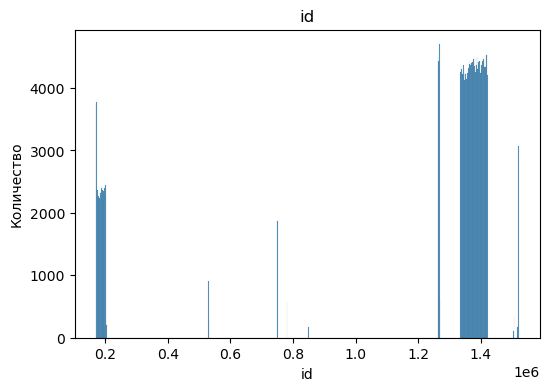

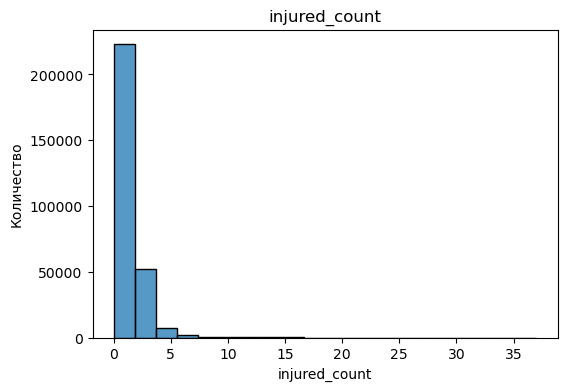

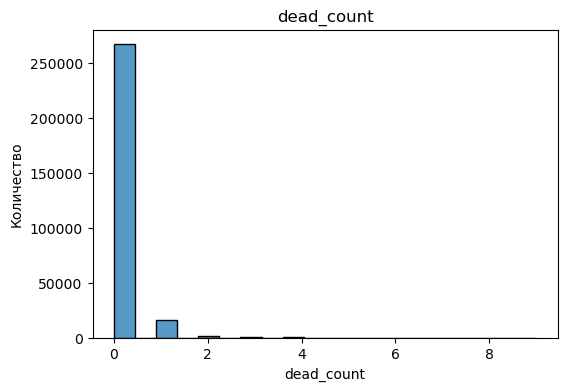

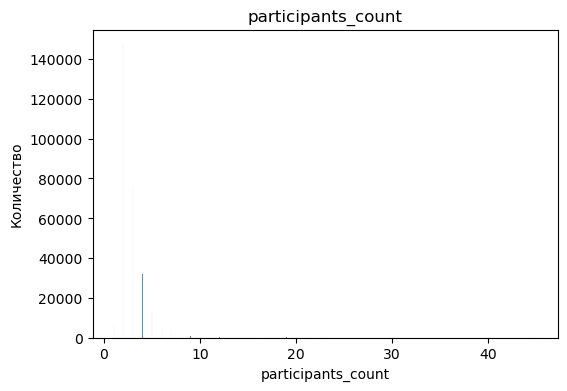

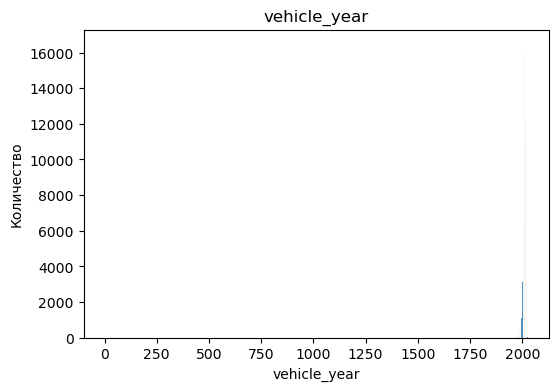

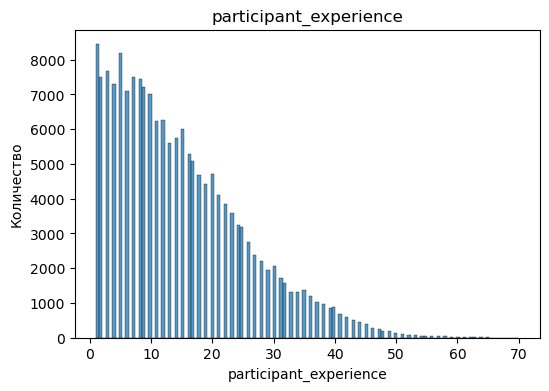

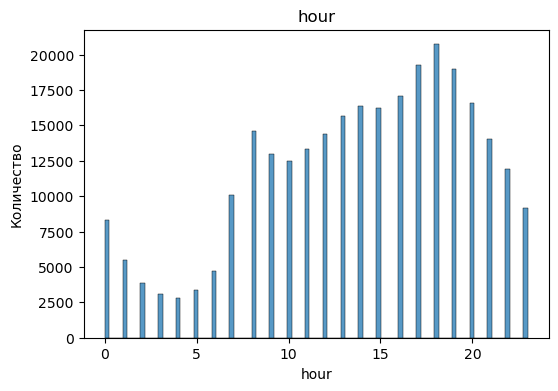

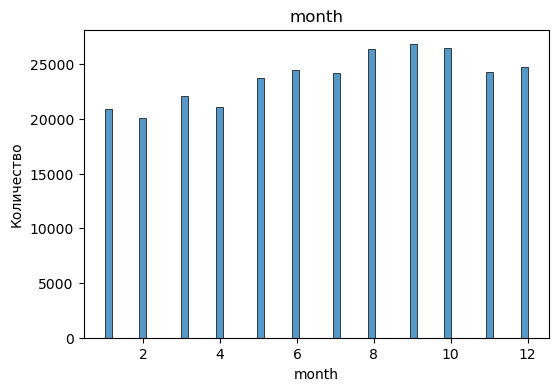

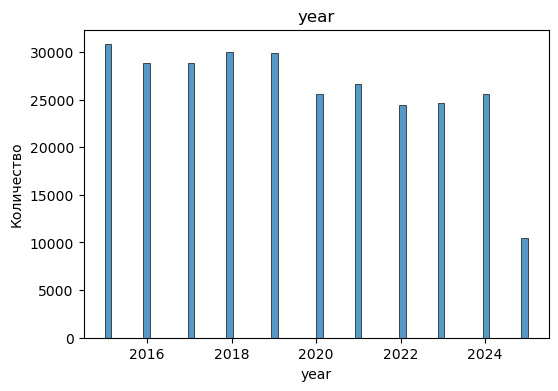

In [53]:
for col in new_data.select_dtypes(include=['number']).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(new_data[col]) 
    plt.title(col)
    plt.ylabel('Количество')
    plt.show()
    

- Явная ошибка в данных колонке vehicle_year. 
- Стоит посмотреть на ДТП с большим количеством пострадавших **(injured_count)** и участников **(participants_count)** . Размах значений соразмерен. Скорее всего это крупные аварии с участием нескольких машин, либо с участием автобусов.


In [54]:
new_data[new_data.injured_count > 16].brand_norm.value_counts()

brand_norm
Автобусы              210
Иномарки легковые       4
Спецтехника             3
Грузовой транспорт      1
Name: count, dtype: int64

Всё ок

In [55]:
# Посмотрим на авто 100 летней давности выпуска
new_data.query('vehicle_year < 1930')[['vehicle_brand','vehicle_year']]

,vehicle_brand,vehicle_year
83896,TOYOTA,1919.0
154205,Прочие марки ТС,1.0
165673,Прочие марки ТС,1.0
222972,ВАЗ,1907.0
222973,ВАЗ,1907.0
224439,None,1.0
238560,FORD,1900.0
243391,None,1.0
246194,None,1.0
251471,None,1.0


In [56]:
new_data.loc[new_data.vehicle_year < 1930,'vehicle_year'] = np.nan

Предположу , что все автомобили выпуском ранее 1930 в данных содержат ошибку. Тех что старше 1970 немного и больших искажений в случае ошибки не будет.

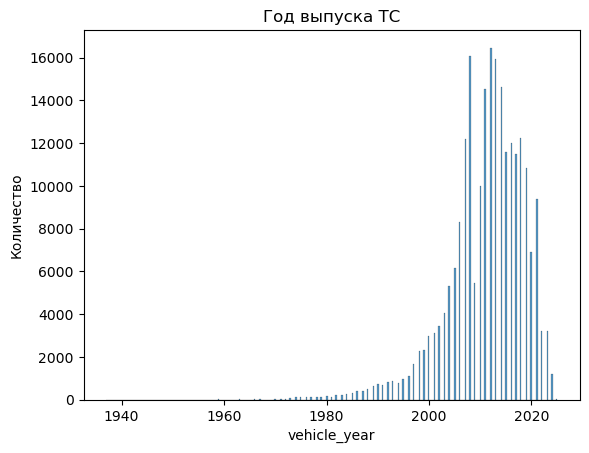

In [57]:
sns.histplot(new_data['vehicle_year']) 
plt.title('Год выпуска ТС')
plt.ylabel('Количество')
plt.show()

По году выпуска теперь нормальное распределние с левой ассиметрией. Как и должно быть. 

-------

## 3 Исследовательский анализ данных

In [58]:
dtp_has_fatal = new_data.groupby('id')['instant_death'].max().reset_index()
dtp_has_fatal.columns = ['id', 'instant_death']

# уникальные ДТП с атрибутом события(айдишник)
dtp_data = new_data.drop_duplicates(subset=['id'], keep='first')[
    ['id', 'light', 'weather_norm', 'severity','category', 'dead_count', 'participants_count', 'injured_count', 'parent_region',
     'road_condition_norm', 'pedestrian_crossing_type','hour', 'month', 'year', 'season']
].copy()

# Присоединяем признак смертности
dtp_data = dtp_data.merge(dtp_has_fatal, on='id', how='left')

print(f" {green}{bold}Создана таблица ДТП:{reset} {bold}{len(dtp_data)}{reset} {green}{bold}уникальных событий")

 Создана таблица ДТП: 117568 уникальных событий


In [59]:
dtp_data['year'] = dtp_data['year'].astype(int)

In [60]:
data.head(1)

,id,tags,light,nearby,region,scheme,address,weather,category,datetime,severity,dead_count,injured_count,parent_region,road_conditions,participants_count,participant_categories,point.lat,point.long,vehicle_year,vehicle_brand,vehicle_color,vehicle_model,vehicle_category,participant_role,participant_gender,participant_health,participant_experience,participant_violations,participant_type,pedestrian_crossing_type,weather_norm,hour,month,year,season,road_condition_norm,participant_role_norm,vehicle_category_norm,violation_norm,instant_death,brand_norm
0,749814,Дорожно-транспортные происшествия,Светлое время суток,"Многоквартирные жилые дома, Тротуар, пешеходная дорожка",moskv,200,None,Ясно,Столкновение,2023-06-14 17:55:00,Легкий,0,1,Москва,Сухое,2,Все участники,55.84385,37.431085,2021.0,Прочие марки ТС,Многоцветный,Прочие марки и модели ТС,Иные ТС,Водитель,Мужской,Не пострадал,1.0,Нарушение правил расположения ТС на проезжей части,driver_or_passenger,Без указанного перехода,Ясно,17,6,2023,Лето,Сухое,Водитель,Прочие ТС,Прочие,False,Неизвестно


In [61]:
part_data = new_data[
    ['id', 'participant_role_norm', 'parent_region', 'violation_norm','brand_norm', 'participant_gender', 
     'vehicle_brand', 'vehicle_category_norm','vehicle_year', 'participant_experience', 
     'instant_death']
].copy()

In [62]:
# Оставим только последние 4 года
dtp_by_region_season = (dtp_data.query('year > 2020').
                        groupby(['parent_region', 'year', 'season'])
                        .size().reset_index(name='dtp_count'))
# чередность для графика
season_order = {'Зима': 0, 'Весна': 1, 'Лето': 2, 'Осень': 3}
dtp_by_region_season['time_axis'] = dtp_by_region_season['year'] + dtp_by_region_season['season'].map(season_order) / 4.0


sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2', 'font.family': 'Arial'}, font_scale=1.8)

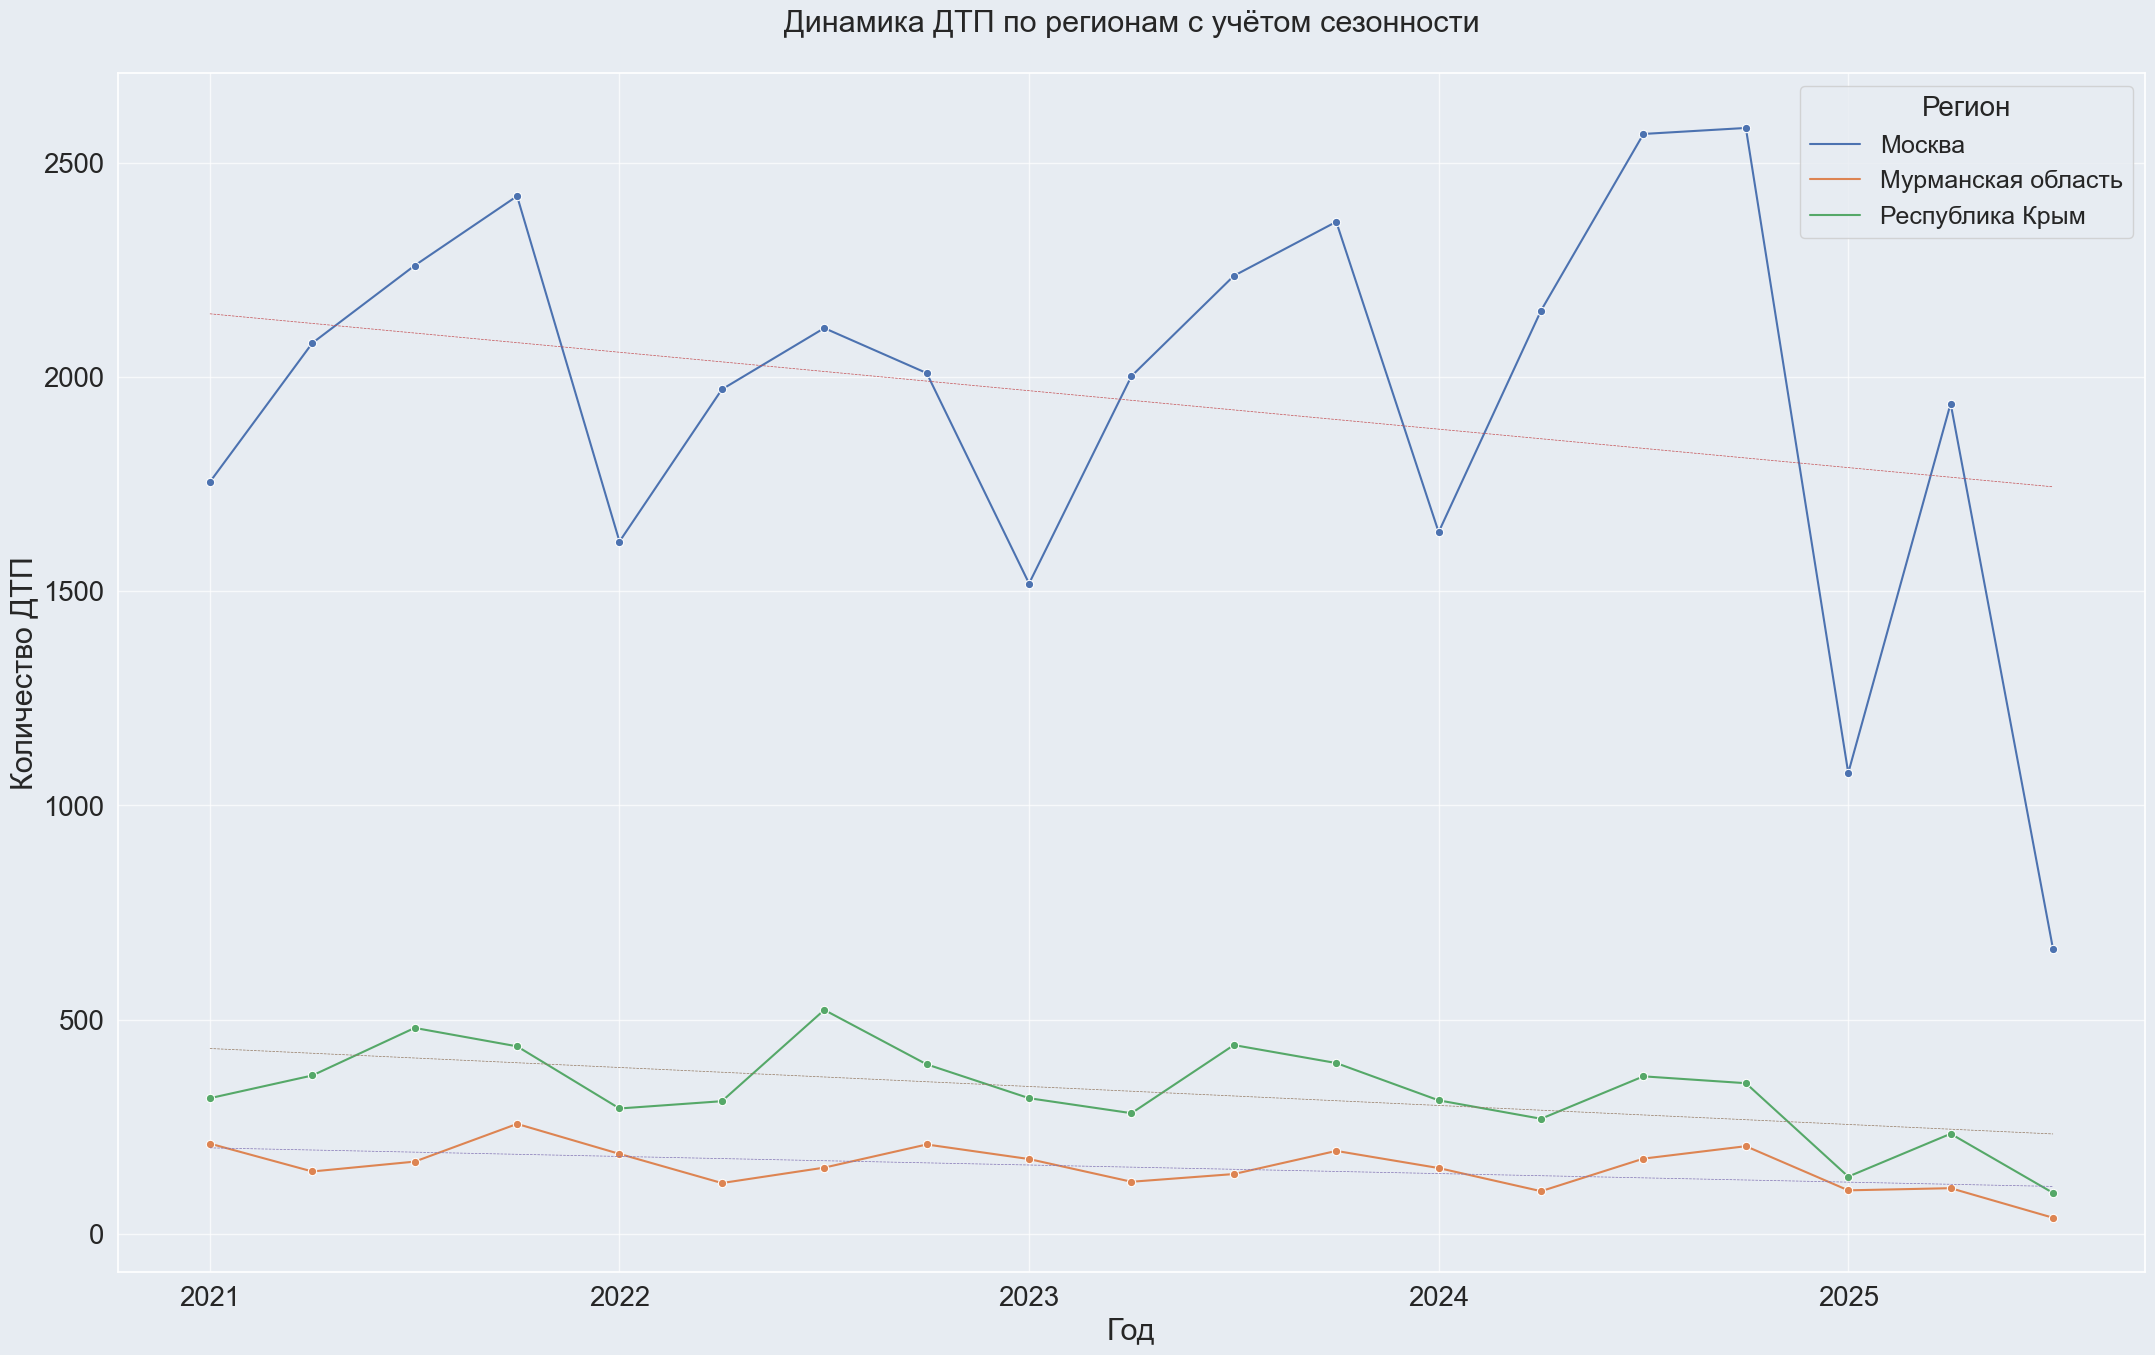

In [63]:
plt.figure(figsize=(22, 14))

sns.lineplot(
    data=dtp_by_region_season,
    x='time_axis',
    y='dtp_count',
    hue='parent_region',
    marker='o',
    linewidth=1.5,
    markersize=6
)
for region in dtp_by_region_season['parent_region'].unique():
    region_data = dtp_by_region_season[dtp_by_region_season['parent_region'] == region]
    sns.regplot(
        data=region_data,
        x='time_axis',
        y='dtp_count',
        scatter=False,
        ci=None,                
        line_kws={'linewidth': 0.5, 'linestyle': '--'}  
    )
plt.xlabel('Год', fontsize=22)
plt.ylabel('Количество ДТП', fontsize=22)
plt.title('Динамика ДТП по регионам с учётом сезонности', fontsize=22,pad =30 )
plt.legend(title='Регион', fontsize=18, title_fontsize=20)
plt.grid(True, alpha=0.7)


plt.tight_layout()
plt.show()

Если взглянуть на общие графики , то можно отметить схожую динамику для всех регионов:

- **Москва** значительно превосходит **Крым и Мурманскую область** по абсолютному количеству ДТП - в среднем в 5-7 раз, что объясняется высокой плотностью транспортного потока и более сложной дорожной инфраструктурой.
- Сезонная динамика немного различается по регионам. Но об этом чудь позже. 
- Количество ДТП упало, по сравнению с 2021м годом и имеет тенденцию с сокращению. 

На следующем графике представлена нормализованная динамика ДТП, где значения выражены в процентах от максимального количества ДТП за год в каждом регионе, что позволит сравнить сезонные отличия независимо от абсолютных объёмов.

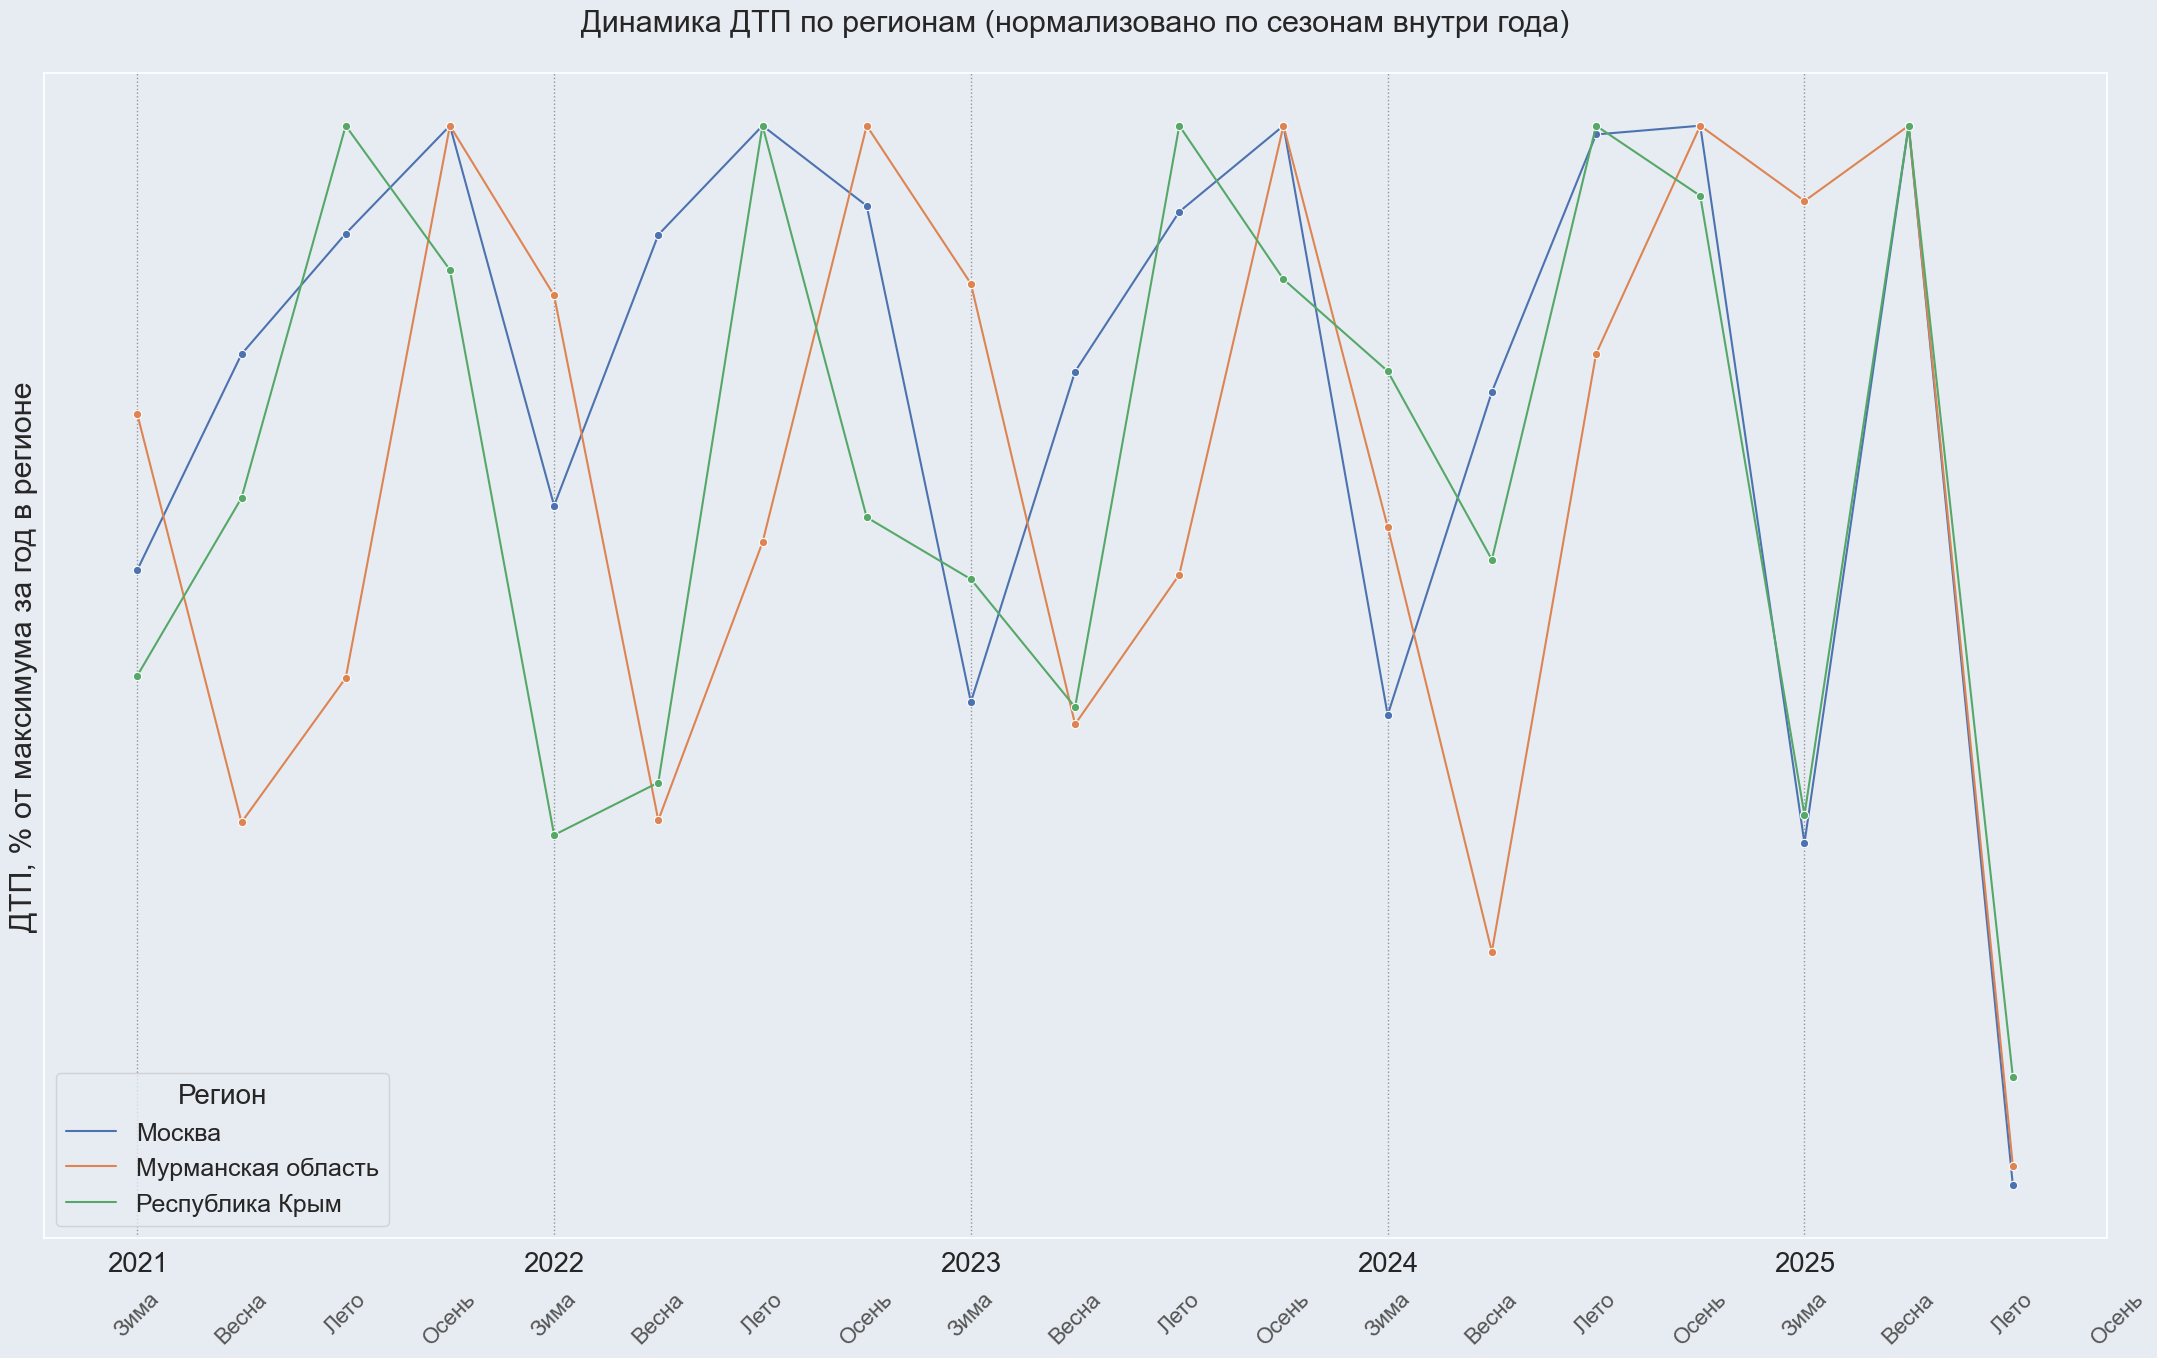

In [64]:
dtp_by_region_season = (dtp_data.query('year > 2020')
                        .groupby(['parent_region', 'year', 'season'])
                        .size().reset_index(name='dtp_count'))

season_order = {'Зима': 0, 'Весна': 1, 'Лето': 2, 'Осень': 3}
dtp_by_region_season['season_order'] = dtp_by_region_season['season'].map(season_order)
dtp_by_region_season['time_axis'] = dtp_by_region_season['year'] + dtp_by_region_season['season_order'] / 4.0

# процент от максимального значения ДТП в регионе за конкретный год
dtp_by_region_season['dtp_pct_of_year_max'] = (
    dtp_by_region_season.groupby(['parent_region', 'year'])['dtp_count']
    .transform(lambda x: (x / x.max()) * 100)
)

# Настройка стиля
sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2', 'font.family': 'Arial'}, font_scale=1.8)
plt.figure(figsize=(22, 14))

# график
sns.lineplot(
    data=dtp_by_region_season,
    x='time_axis',
    y='dtp_pct_of_year_max',
    hue='parent_region',
    marker='o',
    linewidth=1.5,
    markersize=6
)

# Подписи сезонов 
for year in dtp_by_region_season['year'].unique():
    for season, offset in season_order.items():
        x_pos = year + offset / 4.0
        plt.text(x_pos, plt.ylim()[0] - plt.ylim()[1]*0.03, season, 
                 ha='center', va='top', fontsize=16, rotation=45, color='#555')

plt.xlabel('')
plt.ylabel('ДТП, % от максимума за год в регионе', fontsize=22)
plt.title('Динамика ДТП по регионам (нормализовано по сезонам внутри года)', fontsize=22, pad=30)
plt.legend(title='Регион', fontsize=18, title_fontsize=20)
plt.yticks([])
plt.grid(True, axis='x', linestyle=':', linewidth=1, alpha=0.8, color='grey')

plt.xticks(ticks=sorted(dtp_by_region_season['year'].unique()), labels=sorted(dtp_by_region_season['year'].unique()))

plt.tight_layout()
plt.show()

- Наименьшее количество ДТП в Мурманской области приходится на весну, а в Москве - на зиму. В Крыму же сезонные минимумы по годам перемещаются между зимой и весной.
- Пики для всех регионов приходятся на лето и осень, после чего идут на спад.
- Стоит отметить отсутсвие сезонного спада для Мурманской области зимой 2025 года. Относитиельные значения находятся на уровне сезонных максимумах, что противоречит установленной динамике.

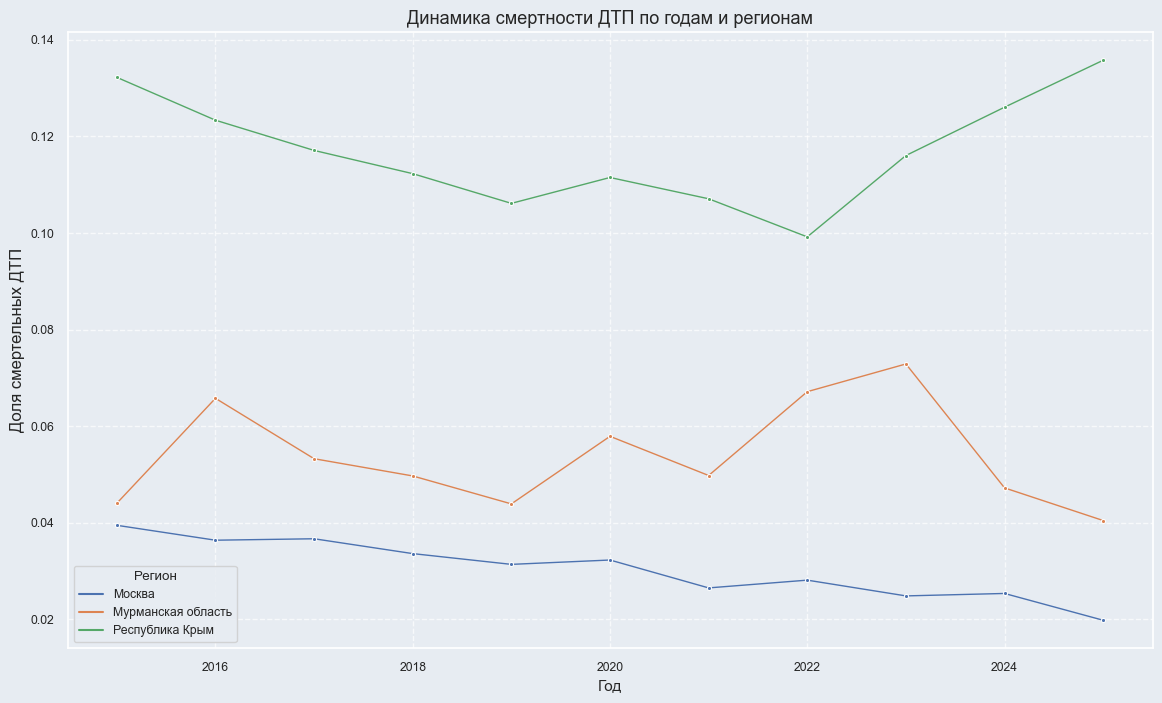

In [65]:
# Агрегируем по году и региону
yearly_mortality = dtp_data.groupby(['parent_region', 'year'])['instant_death'].agg(['mean', 'count']).reset_index()
yearly_mortality.columns = ['parent_region', 'year', 'mortality_rate', 'total_dtp']
sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2', 'font.family': 'Arial'}, font_scale=0.8)


plt.figure(figsize=(14, 8))
sns.lineplot(data=yearly_mortality, x='year', y='mortality_rate', hue='parent_region', marker='.', linewidth=1)
plt.title('Динамика смертности ДТП по годам и регионам', fontsize=13)
plt.xlabel('Год', fontsize=11)
plt.ylabel('Доля смертельных ДТП', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Регион')
plt.show()

Анализ динамики смертности в ДТП выявил значительные межрегиональные различия:

- Наиболее выраженная положительная тенденция наблюдается в **Москве**, где за восьмилетний период доля ДТП со смертельным исходом сократилась практически вдвое, что свидетельствует о высокой эффективности принимаемых мер.
- Подобная динамика наблюдалась и в **Республике Крым**, но была прервна в 2022 году, что, вероятно, связанно с началом СВО.
- В **Мурманской области** динамика смертности менее стабильна и чётких долгосрочных трендов не прослеживается. Резкий рост числа ДТП со смертельным исходом в 2021 году сменился снижением к 2023 году, вернувшись к уровню предыдущих лет.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


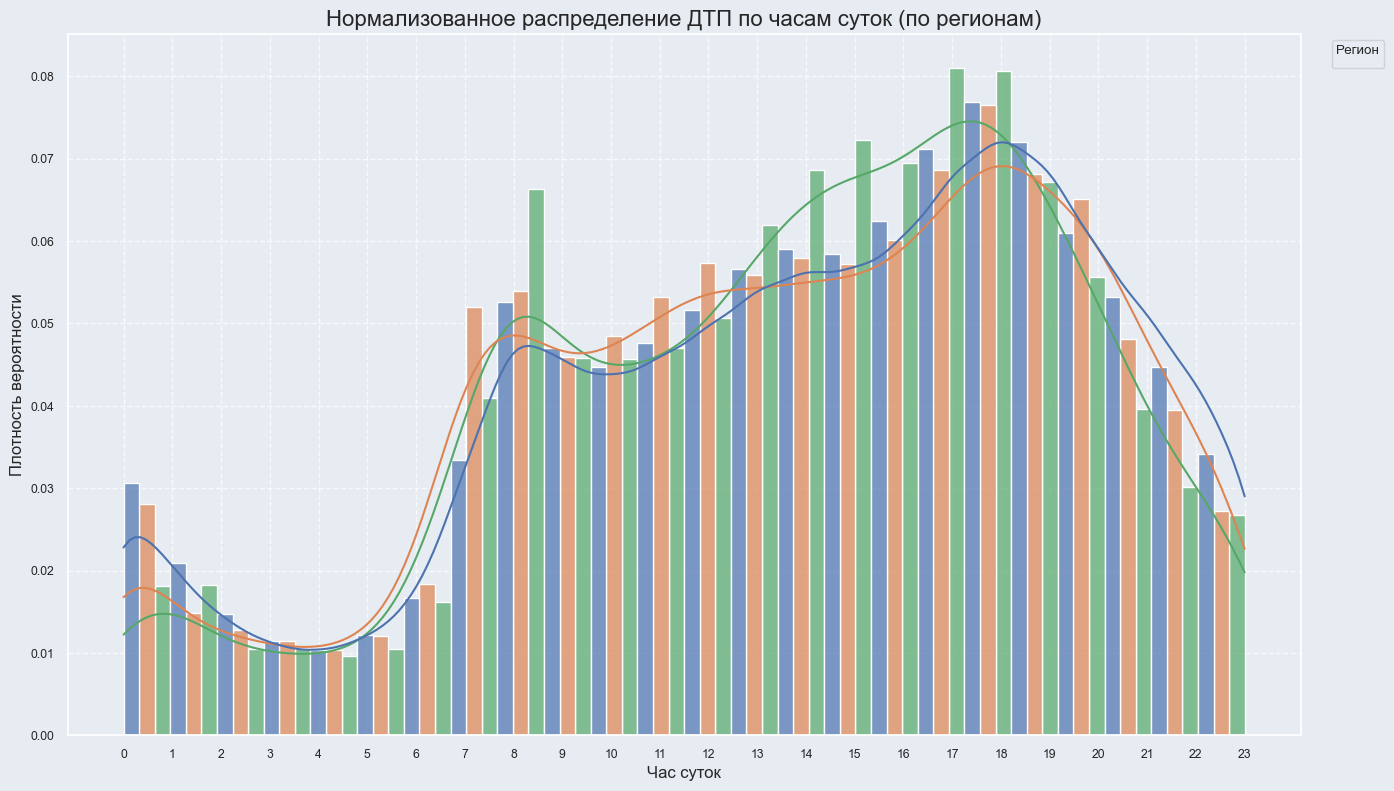

In [66]:
sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2', 'font.family': 'Arial'}, font_scale=0.8)
plt.figure(figsize=(14, 8))
sns.histplot(
    data=dtp_data,
    x='hour',
    bins=24,
    kde=True,
    hue='parent_region',
    multiple='dodge',
    stat='density',           
    common_norm=False,      
    alpha=0.7                 
)

plt.title('Нормализованное распределение ДТП по часам суток (по регионам)', fontsize=16)
plt.xlabel('Час суток', fontsize=12)
plt.ylabel('Плотность вероятности', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Регион', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Значимых различий между регионами по количеству ДТП в разрезе времени суток не наблюдается. Во всех регионах отмечается схожая динамика: резкий рост аварийности в начале рабочего дня (около 8:00), после чего уровень стабилизируется и постепенно нарастает до максимума к его окончанию (18:00), а затем следует резкий спад до минимальных значений ночью. 

---

### Корреляционный анализ

Далее я проведу корреляционный анализ, чтобы выявить статистические взаимосвязи между ключевыми признаками (погодные условия, освещённость, тип дороги и другие) с уровнем смертности при ДТП.

Моя задача определить, какие факторы оказывают наибольшее влияние на вероятность летального исхода, и проверить гипотезы, сформированные на основе предыдущих классификаций.

Анализ поможет выделить приоритетные направления для профилактики ДТП со смертельным исходом и обосновать целевые меры в рамках наиболее влияющих на смертность признаков.

In [67]:
def analyze_column(df, region, col, top_n=20, caption="Топ объектов" , dftype='Смертность при ДТП' ):
    """
    Анализирует распределение ДТП и смертности по указанному признаку (колонке) в выбранном регионе.
    Возвращает стилизованную таблицу с топ-N значениями, отсортированными по уровню смертности (убывание).

    Функция:
    - Фильтрует данные по региону.
    - Исключает пустые, NaN и некорректные значения в целевой колонке.
    - Группирует по значениям целевой колонки, оставляя только те, где количество ДТП > 30.
    - Рассчитывает:
        - Количество ДТП,
        - Количество смертей,
        - Процент аварий от общего числа в выборке,
        - Уровень смертности (% смертей от числа ДТП).
    - Сортирует по убыванию смертности.
    - Стилизует таблицу: цветовые градиенты, проценты, подписи.
    - Отображает среднюю смертность по всем ДТП в регионе для сравнения.

    аргументыв:
        df (pd.DataFrame): Исходный DataFrame с данными о ДТП.
        region (str): Название региона для фильтрации (должно точно совпадать со значениями в 'parent_region').
        col (str): Название анализируемой колонки (например, 'weather', 'road_type', 'light').
        top_n (int, optional): Количество топ-записей для отображения. По умолчанию 20.
        caption (str, optional): Заголовок таблицы. По умолчанию "Топ объектов".
        dftype (str, optional): будет меняться для двух датасетов. В датасете ДТП - наличие мгновенной смерти в отедльном ДТП,
        а там где участники - для всех участников дорожно-транспортного происшествия.

       
    """
    filtered_df = df[['parent_region', col, 'instant_death']].copy()
    
    # Приводим parent_region к строке и фильтруем по региону
    filtered_df['parent_region'] = filtered_df['parent_region'].astype(str).str.strip()
    filtered_df = filtered_df[filtered_df['parent_region'] == region]
    
    # Обрабатываем целевую колонку
    filtered_df[col] = filtered_df[col].astype(str).str.strip()
    filtered_df = filtered_df[filtered_df[col].notna() & (filtered_df[col] != 'nan') & (filtered_df[col] != '')]
     
    # Группируем
    result = (filtered_df.groupby(col, as_index=False)
              .agg(Количество=(col, 'size'), Смерти=('instant_death', 'sum'))
              .query('Количество > 30')
              .nlargest(top_n, 'Количество'))      

    # Считаем общую среднюю смертность по ВСЕМ ДТП в выбранном регионе
    region_df = df[df['parent_region'] == region]
    total_mean_mortality = (region_df['instant_death'].sum() / len(region_df)) * 100 if len(region_df) > 0 else 0

    # Проценты и смертность для топа
    result['Процент аварий'] = (result['Количество'] / result['Количество'].sum() * 100).round(2)
    result['Смертность'] = (result['Смерти'] / result['Количество'] * 100).round(2)
    
    # Относительный риск (во сколько раз выше/ниже среднего)
    if total_mean_mortality > 0:
        result['Относительный риск'] = (result['Смертность'] / total_mean_mortality).round(2)
    else:
        result['Относительный риск'] = 0.0

    
    result = result.sort_values('Смертность', ascending=False)
    
    # Стиль
    styled = (result.style
              .format({
                  'Процент аварий': '{:.2f}%',
                  'Смертность': '{:.2f}%',
                  'Относительный риск': '{:.2f}x'
              })
              .background_gradient(subset=['Количество'], cmap='Reds', vmax=1000000)
              .background_gradient(subset=['Процент аварий'], cmap='Reds', vmax=100)
              .background_gradient(subset=['Смертность'], cmap='Reds', vmax=40)
              .background_gradient(subset=['Смерти'], cmap='Reds', vmax=100000)
              .background_gradient(subset=['Относительный риск'], cmap='Reds', vmax=3.0)  # до 3x риска
              .bar(color='Reds', subset=['Процент аварий'])
              .bar(color='Reds', subset=['Смертность'])
              .bar(color='Reds', subset=['Относительный риск'])  # бар и для нового столбца
              .set_properties(**{'text-align': 'center', 'font-size': '14px', 'border': '1px solid #ccc'})
              .set_caption(
                  f'<b style="color: #000; font-size: 16px">{caption} <br>'
                  f'<br>'
                  f'Регион:<b style="color: #42AAFF; font-size: 14px"> {region}<br>'
                  
                  f' <b style="color: #000; font-size: 16px"> {dftype} <b style="color: #c33f; Средняя смертность:  <span style="color:#F08080">{total_mean_mortality:.2f}%</b>'
              )
              .hide(axis='index'))
    
    return styled

`Поскольку GitHub не отображает стилизацию pandas-таблиц (созданную через .style), в отличие от Jupyter Notebook, я их оживлю через скриншоты.`

![Влияние освещения](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/light.png)

In [68]:
#analyze_column(dtp_data, "Москва" , 'light', 45, "Влияние освещения", 'Смертность при ДТП:')

In [69]:
#analyze_column(dtp_data, "Республика Крым" , 'light', 45, "Влияние освещения")

In [70]:
#analyze_column(dtp_data, "Мурманская область" , 'light', 45, "Влияние освещения")

Темное время суток, без установленного освещения - наиболее критический фактор.
- В **Москве** смертность в ДТП при таких обстоятельствах превышает средние показатели более чем в 6 раз, а при неисправном освещении - в 4 раза. Хотя подобные случаи относительно редки, их последствия всегда имеют трагический характер.

- В **Крыму** относительный риск ДТП при отсутствующем освещении значительно ниже чем в Москве, однако частота таких аварий выше среднего в 30 раз, что формирует очень тревожную статистику. Это указывает на необходимость усиления работы дорожных служб по устранению данных факторов риска.

- Похожая ситуация и в **Мурманской области**. Высокий процент аварий и смертность выше среднего примерно в два раза в условиях отсутсвующего освещения.

-----

![Влияние погоды](https://github.com/Raleshin/Raleshin/raw/main/Анализ%20ДТП/assets/Погода%201-2.png)

![Влияние погоды](https://github.com/Raleshin/Raleshin/raw/main/Анализ%20ДТП/assets/Погода%203.png)

In [71]:
#analyze_column(dtp_data, "Москва" , 'weather_norm', 45, "Влияние погоды")

In [72]:
#analyze_column(dtp_data, "Республика Крым" , 'weather_norm', 45, "Влияние погоды")

In [73]:
#analyze_column(dtp_data, "Мурманская область" , 'weather_norm', 45, "Влияние погоды")

- Наличие тумана повышает среднюю смертность при ДТП примерно в два раза для каждого региона. Процент аварий в таких условиях невысок, но и не отметить его нельзя.
- Относительный риск ДТП в **Мурманской области** значительно возрастает во время снегопадов, занимающих вторую позицию в рейтинге опасных факторов. Недостаточно оперативная работа дорожных служб усугубляет ситуацию.
- В **Москве** относительный риск ДТП во время дождя превышает средние показатели, однако значения остаются в пределах приемлемого уровня.

----

![Дорожные условия](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%201.png)

![Дорожные условия](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%202.png)

![Дорожные условия](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%203.png)

In [74]:
#analyze_column(dtp_data, "Республика Крым" , 'road_condition_norm', 45, "Влияние дорожных условий")

In [75]:
#analyze_column(dtp_data, "Мурманская область" , 'road_condition_norm', 45, "Влияние дорожных условий")

In [76]:
#analyze_column(dtp_data, "Москва" , 'road_condition_norm', 45, "Влияние дорожных условий")

- В **Республике Крым** ДТП при отсутствии освещения составляют аномально высокую долю от общего числа аварий, в то время как остальные факторы либо соответствуют норме, либо имеют низкую представленность
- Парадоксальная ситуация сложилась для **Мурманской области** . Участки дорог обработанные ПГМ приводят к большому (до 15%) аварий, при относительном риске в два раза более высоком, чем при гололедице. Это характерно и для других регионов , но проявляется в относительно меньших значениях. Предположу , что это ложное чувство безопасности, и водители менее осторожны на обработанных трассах, превышая скорость. Так же причиной может быть неравномерная обработка участков дороги. Формально она есть, но не на всей протяженности. И как результтат фатальыне исходы.
- В **Москве** аварии с признаками высокого риска летального исхода фиксируются крайне редко, что свидетельствует об эффективности системы безопасности дорожного движения

----

`Далее часть менее информативных таблиц отражена в сыром виде`

In [77]:
analyze_column(dtp_data, "Мурманская область" , 'month', 45, "Месяц аварии")

month,Количество,Смерти,Процент аварий,Смертность,Относительный риск
11,837,54,10.52%,6.45%,1.19x
8,607,38,7.63%,6.26%,1.15x
2,644,38,8.10%,5.90%,1.09x
4,426,25,5.36%,5.87%,1.08x
1,642,36,8.07%,5.61%,1.03x
12,900,48,11.32%,5.33%,0.98x
5,494,26,6.21%,5.26%,0.97x
10,934,48,11.74%,5.14%,0.95x
9,750,38,9.43%,5.07%,0.93x
7,592,30,7.44%,5.07%,0.93x


In [78]:
analyze_column(dtp_data, "Москва" , 'month', 45, "Месяц аварии")

month,Количество,Смерти,Процент аварий,Смертность,Относительный риск
7,7420,251,8.09%,3.38%,1.08x
11,7755,259,8.45%,3.34%,1.07x
2,6436,215,7.02%,3.34%,1.07x
8,8154,263,8.89%,3.23%,1.03x
12,7658,244,8.35%,3.19%,1.02x
5,8041,256,8.77%,3.18%,1.02x
4,7157,227,7.80%,3.17%,1.01x
10,8446,263,9.21%,3.11%,0.99x
9,8717,265,9.50%,3.04%,0.97x
3,7192,217,7.84%,3.02%,0.97x


In [79]:
analyze_column(dtp_data, "Республика Крым" , 'month', 45, "Месяц аварии")

month,Количество,Смерти,Процент аварий,Смертность,Относительный риск
11,1431,189,8.00%,13.21%,1.14x
12,1555,205,8.69%,13.18%,1.14x
1,1165,152,6.51%,13.05%,1.13x
10,1630,203,9.11%,12.45%,1.08x
9,1715,208,9.59%,12.13%,1.05x
2,1029,122,5.75%,11.86%,1.03x
5,1446,168,8.08%,11.62%,1.00x
4,1230,131,6.87%,10.65%,0.92x
7,1899,200,10.61%,10.53%,0.91x
3,1159,122,6.48%,10.53%,0.91x


----

Проанализировать

In [80]:
part_data['exp_cat'] = (np.where(part_data.participant_experience < 2, 'Новичок',
                        np.where(part_data.participant_experience < 5, 'Опытный',
                        np.where(part_data.participant_experience > 6 ,'Ветеран', np.NaN))))

In [81]:
(analyze_column(part_data[part_data.participant_role_norm == 'Водитель'], 
               "Республика Крым" , 'exp_cat', 45, "Влияние опыта",'Смертность для водителей'))

exp_cat,Количество,Смерти,Процент аварий,Смертность,Относительный риск
Новичок,1705,58,7.47%,3.40%,0.96x
Опытный,3265,101,14.31%,3.09%,0.87x
Ветеран,17843,548,78.21%,3.07%,0.87x


In [82]:
(analyze_column(part_data[part_data.participant_role_norm == 'Водитель'], 
               "Мурманская область" , 'exp_cat', 45, "Влияние опыта",'Смертность для водителей'))

exp_cat,Количество,Смерти,Процент аварий,Смертность,Относительный риск
Ветеран,8129,160,81.89%,1.97%,1.03x
Опытный,1340,23,13.50%,1.72%,0.90x
Новичок,458,5,4.61%,1.09%,0.57x


In [83]:
(analyze_column(part_data[part_data.participant_role_norm == 'Водитель'],
                "Москва" , 'exp_cat', 45, "Влияние опыта",'Смертность для водителей',))

exp_cat,Количество,Смерти,Процент аварий,Смертность,Относительный риск
Новичок,6280,53,4.94%,0.84%,1.16x
Опытный,17877,142,14.08%,0.79%,1.09x
Ветеран,102849,672,80.98%,0.65%,0.90x


Во всех регионах кроме **Мурманской области** водители с опытом менее трех лет погибают в авариях чаще. В Мурманске относительный риск для ветеранов выше, но это может быть связанос небольшой выборкой для других категорий.

---

In [84]:
#analyze_column(part_data, "Москва" , 'violation_norm', 45, "Тип нарушения",'Смертность для всех участников')

In [85]:
#analyze_column(part_data, "Республика Крым" , 'violation_norm', 45, "Тип нарушения",'Смертность для всех участников')

In [86]:
#analyze_column(part_data,"Мурманская область" ,'violation_norm', 45,"Тип нарушения",'Смертность для всех участников')

![Тип нарушения](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%201.png)

![Тип нарушения](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%202.png)

![Тип нарушения](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%B4%D0%BE%D1%80%D0%BE%D0%B6%D0%BD%D1%8B%D0%B5%20%D1%83%D1%81%D0%BB%D0%BE%D0%B2%D0%B8%D1%8F%203.png)

Наиболее смертоносными нарушениями во всех регионах являются выезд на встречную полосу, опьянение и  комплекс из 5+ нарушений. Их относительный риск в **2-4** раза превышает средний.
- В **Москве** особенно выделяется выезд на встречку (смерность 5.68%, риск 4.03x).
- В **Республике Крым** особенно высока смертность при нарушениях, связанных с перевозкой людей (12.27%), что, вероятно, отражает низкий уровень использования ремней безопасности. Это указывает на необходимость усиления профилактической работы и информирования населения - как со стороны региональных властей, так и ГИБДД. На первом  же месте комплекс 5ти и более нарушений, что говорит о проблеме проверкии и контроля участников движения, до момента аварии. 
- В **Мурманской области** - те же факторы, но с меньшей интенсивностью.


----

In [87]:
#analyze_column(part_data,"Мурманская область" ,'vehicle_category_norm', 45,"Тип транспорта",'Смертность для всех участников')

In [88]:
#analyze_column(part_data,"Москва" ,'vehicle_category_norm', 45,"Тип транспорта",'Смертность для всех участников')


In [89]:
#analyze_column(part_data, "Республика Крым" ,'vehicle_category_norm', 45,"Тип транспорта",'Смертность для всех участников')


![Тип транспорта](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%A2%D0%B8%D0%BF%20%D1%82%D1%80%D0%B0%D0%BD%D1%81%D0%BF%D0%BE%D1%80%D1%82%D0%B0.png)

![Тип транспорта](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%A2%D0%B8%D0%BF%20%D1%82%D1%80%D0%B0%D0%BD%D1%81%D0%BF%D0%BE%D1%80%D1%82%D0%B02.png)

![Тип транспорта](https://github.com/Raleshin/Raleshin/raw/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7%20%D0%94%D0%A2%D0%9F/assets/%D0%A2%D0%B8%D0%BF%20%D1%82%D1%80%D0%B0%D0%BD%D1%81%D0%BF%D0%BE%D1%80%D1%82%D0%B03.png)


В Москве несколько повышенную смертность демонстрируют спортивные автомобили - несмотря на их малое количество. При этом участники ДТП с участием легковых автомобилей в столице оказываются в наиболее безопасных условиях: уровень смертности среди них почти вдвое ниже, чем в Мурманской области, и на 30–40% ниже, чем в Республике Крым.

Пешеходы, будучи наиболее уязвимой категорией участников дорожного движения, демонстрируют как высокую долю в структуре ДТП, так и значительный относительный риск смертности. Крайне остро эта проблема стоит в Республике Крым: смертность пешеходов достигает 13.4%  то есть почти каждый восьмой умирает. Такой уровень риска требует  целенаправленного вмешательства:  от улучшения пешеходной инфраструктуры до усиления профилактических  работ.

### Тепловые карты: влияние комбинаций факторов на тяжесть ДТП

In [90]:
def plot_risk_heatmap(data, factor1, factor2,                  
                     title='', figsize=(12, 8)):
    """
    Построение тепловой карты риска смертельного исхода
    
    Params:
    - data: DataFrame с данными
    - factor1: первый фактор (строки)
    - factor2: второй фактор (столбцы)    
    - title: заголовок графика
    - figsize: размер графика
    """
    
    # Создаем сводную таблицу
    pivot_table = data.pivot_table(
        values='instant_death', 
        index=factor1, 
        columns=factor2, 
        aggfunc=np.mean,
        fill_value=0
    )
    
    # Настройка стиля
    sns.set(rc={'axes.facecolor': '#e7ecf2', 
                'figure.facecolor': '#e7ecf2', 
                'font.family': 'Arial'}, 
            font_scale=0.95)
    
    # Построение графика
    plt.figure(figsize=figsize)
    sns.heatmap(pivot_table, annot=True, fmt='.2%', cmap='Reds', vmax=0.4,
                cbar_kws={'label': f'Вероятность смертельного исхода'})
    plt.title(title, pad = 30, size = 16 )
    plt.ylabel(' ')
    plt.xlabel(' ')
    plt.tight_layout()
    plt.show()
    
    

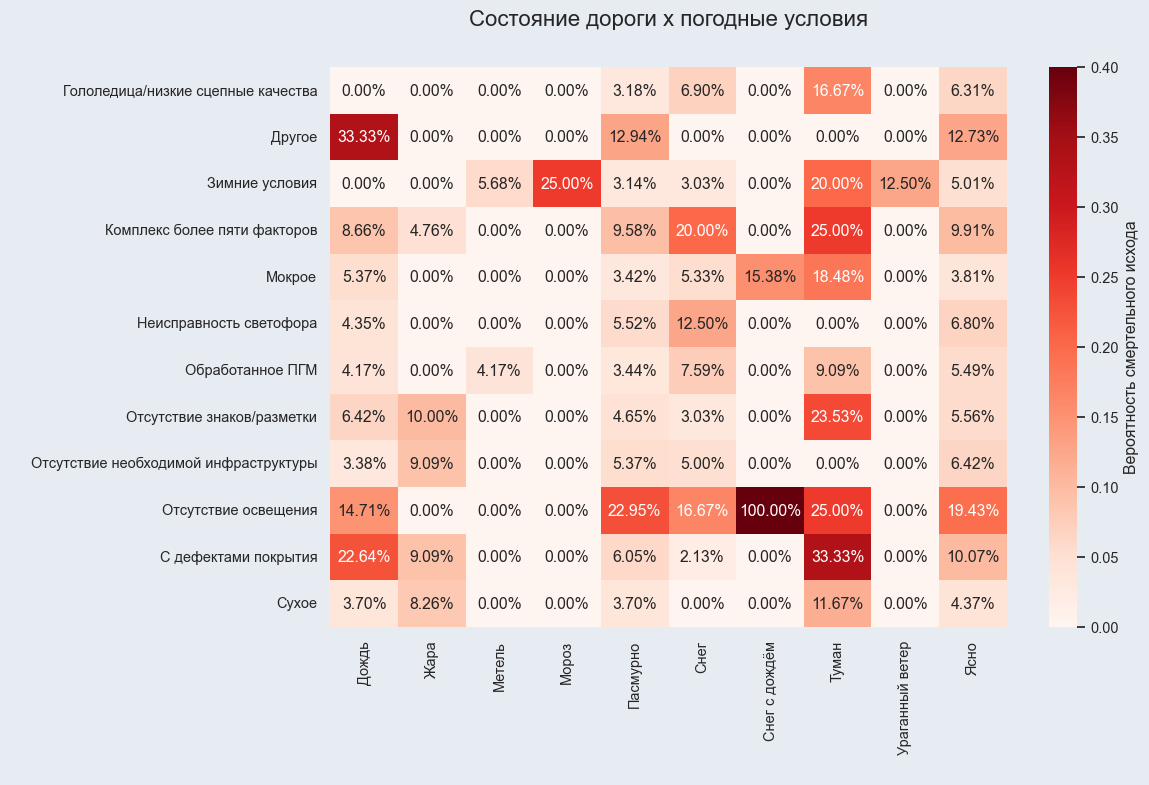

In [91]:
(plot_risk_heatmap(dtp_data,  
                   factor1='road_condition_norm',
                   factor2= 'weather_norm',
                   title = 'Состояние дороги x погодные условия'))

Как было показано ранее, туман и отсутствие необходимого освещения (как проявление дефектов дорожной инфраструктуры) являются наиболее опасными факторами, резко повышающими вероятность смертельного исхода при ДТП.

Остальные неблагоприятные условия зачастую проявляют свою критичность именно в сочетании с этими двумя признаками.

Также высокий уровень опасности у комбинации дождя и дефектов дорожного покрытия: вода скапливается в неровностях, вызывая аквапланирование, скрывает ямы и выбоины, что может привести к потере управления, заносу и серьёзной аварии.

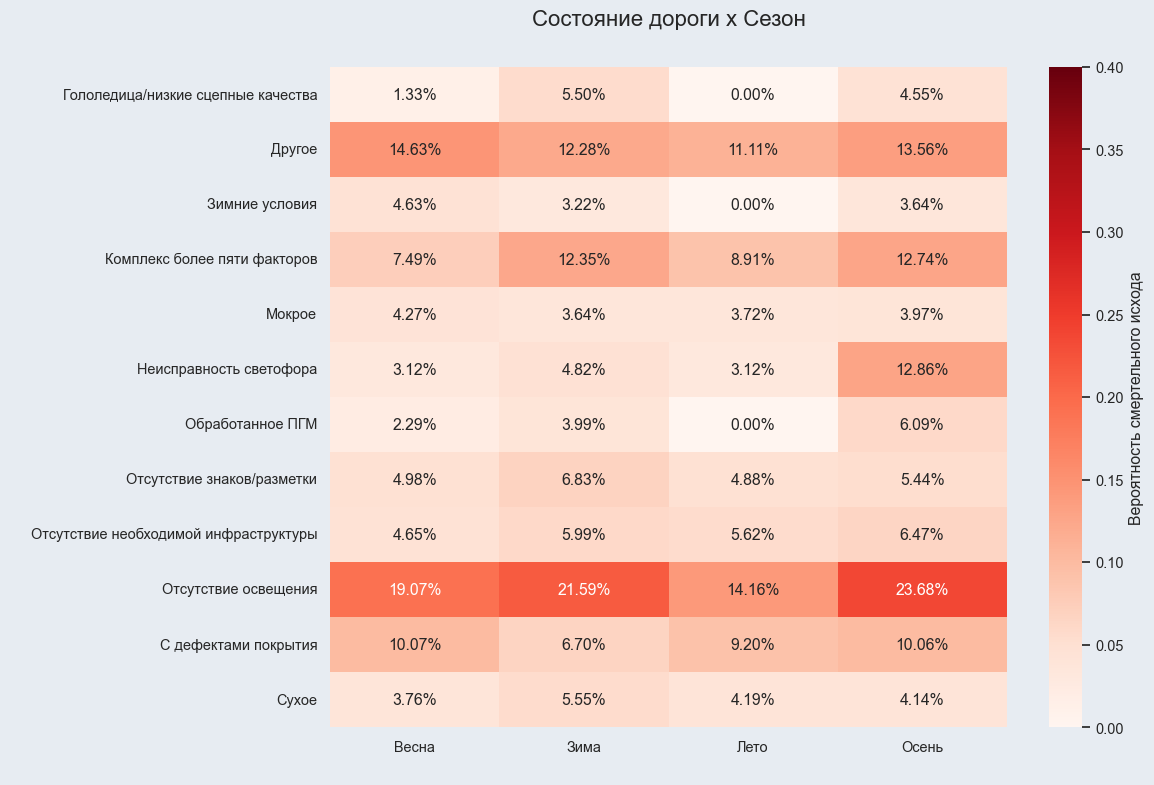

In [92]:
(plot_risk_heatmap(dtp_data,  
                   factor1='road_condition_norm',
                   factor2= 'season',
                   title = 'Состояние дороги x Сезон'))

Ни одного случая ДТП летом при наличии зимних признаков: данные корректны.

Несмотря на объективную сложность управления автомобилем в зимних условиях, именно у  осени худшая статистика по смертельным ДТП. Вероятно, это связано с переходным периодом к зиме: резкими перепадами температур, приводящими к обледенению дорог, наступлением темноты в конце рабочего дня, недостаточной подготовкой транспортных средств к зимнему сезону, а также ростом интенсивности дорожного движения из-за возобновления учебной и рабочей активности.  

### Тепловые карты: влияние комбинаций факторов на тяжесть ДТП для всех участников

In [93]:
part_data.head(1)

,id,participant_role_norm,parent_region,violation_norm,brand_norm,participant_gender,vehicle_brand,vehicle_category_norm,vehicle_year,participant_experience,instant_death,exp_cat
0,749814,Водитель,Москва,Прочие,Неизвестно,Мужской,Прочие марки ТС,Прочие ТС,2021.0,1.0,False,Новичок


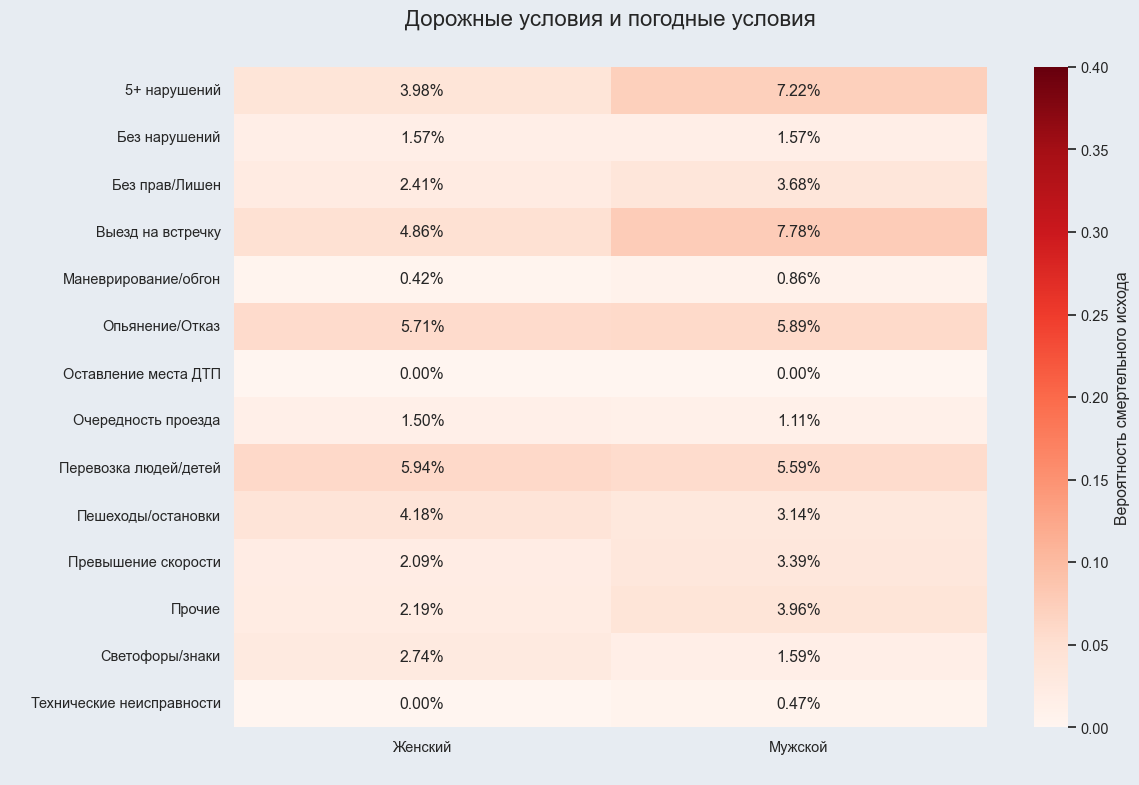

In [94]:
(plot_risk_heatmap(part_data,  
                   factor1='violation_norm',
                   factor2= 'participant_gender',
                   title = 'Дорожные условия и погодные условия'))

В целом ДТП с участием женщин менее  смертнельны по сравнению с авариями с мужчинами; лишь в отдельных категориях:
- Очередность проезда
- Наезд на пешеходов / нарушения правил движения на остановках.
- Игнорирование знаков / сигналов светофора.

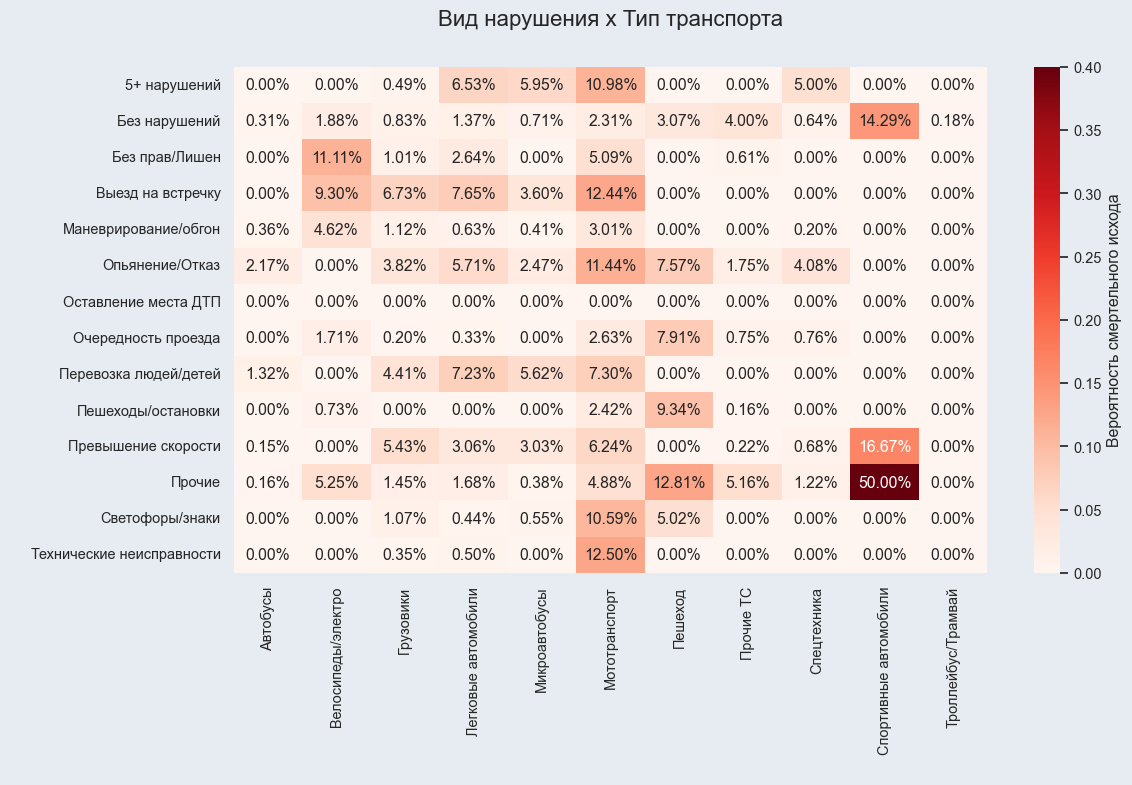

In [95]:
(plot_risk_heatmap(part_data,  
                   factor1='violation_norm',
                   factor2= 'vehicle_category_norm',
                   title = 'Вид нарушения x Тип транспорта'))

## Проверка гипотез

### Гипотеза №1:

Тип пешеходного перехода (**регулируемый / нерегулируемый**) оказывает статистически значимое влияние на вероятность мгновенной гибели пешехода при ДТП.

**Обоснование гипотезы:**

Интуитивно предполагается, что регулируемые переходы безопаснее, поскольку движение контролируется светофорами. Однако на практике и водители, и пешеходы могут снижать бдительность, полагаясь на разрешающий сигнал.

**Выбор статистического критерия:**

Критерий: Хи-квадрат Пирсона  для таблицы сопряжённости.

**Обоснование выбора статистического теста:** 
- Зависимая переменная - бинарная (instant_death).
- Независимая переменная - категориальная (pedestrian_crossing_type).
- Цель - проверить наличие статистически значимой связи между двумя категориальными переменными.
- Выборка большая (n > 1000), распределение соответствует требованиям критерия.
- Уровень значимости: a = 0.05 

**Нулевая гипотеза H₀ :**

Нет разницы - вероятность мгновенной смерти одинакова на регулируемых и нерегулируемых переходах. 

**Альтернатива H₁:**

Разница есть - вероятность мгновенной смерти разная. 

In [96]:
#  Фильтруем данные: мгновенные смерти на регулируемых и нерег. ререходах
regulated = dtp_data[
    (dtp_data['category'] == 'Наезд на пешехода') & 
    (dtp_data['pedestrian_crossing_type'] == 'Регулируемый пешеходный переход')
]['instant_death']

unregulated = dtp_data[
    (dtp_data['category'] == 'Наезд на пешехода') & 
    (dtp_data['pedestrian_crossing_type'] == 'Нерегулируемый пешеходный переход')
]['instant_death']

# cчитаем количество наблюдений и процент мгновенных смертей
n_reg = len(regulated)
n_unreg = len(unregulated)
pct_reg = regulated.mean() * 100
pct_unreg = unregulated.mean() * 100

print(f"{bold} Размеры групп:{reset}")
print(f" Регулируемые переходы:   {bold}{red}{n_reg}{reset} случаев   {bold}{red}{pct_reg:.2f}%{reset} мгновенных смертей")
print(f" Нерегулируемые переходы: {bold}{red}{n_unreg}{reset} случаев {bold}{red} {pct_unreg:.2f}%{reset} мгновенных смертей")



contingency_table = pd.crosstab(
    dtp_data[dtp_data['category'] == 'Наезд на пешехода']['pedestrian_crossing_type'],
    dtp_data[dtp_data['category'] == 'Наезд на пешехода']['instant_death']
)

# хи-квадрат тест
from scipy.stats import chi2_contingency
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n Результаты статистического теста:")
print(f"   Хи-квадрат: {bold}{chi2:.3f}")
print(f"   p-value: {bold}{p_value:.4f}")
print('')
print(f'{bold}Размер эффекта:{reset}')
print(f'Риск мгновенной смерти на регулируемых переходах на {bold}{red}{((pct_reg/pct_unreg-1) * 100).round(2)}{reset} % выше, чем на нерегулируемых. ')

 Размеры групп:
 Регулируемые переходы:   6274 случаев   4.88% мгновенных смертей
 Нерегулируемые переходы: 15309 случаев  3.91% мгновенных смертей

 Результаты статистического теста:
   Хи-квадрат: 159.190
   p-value: 0.0000

Размер эффекта:
Риск мгновенной смерти на регулируемых переходах на 24.86 % выше, чем на нерегулируемых. 


Статистический тест показал, что разница в доле мгновенных смертей между регулируемыми и нерегулируемыми пешеходными переходами статистически значима (p-value < 0.0001).
-  наблюдаемая разница не является случайной - она отражает реальный эффект.

**Таким образом, гипотеза подтверждается: тип пешеходного перехода влияет на вероятность мгновенной гибели пешехода.** 

---

### Гипотеза №2:

Тип автомобиля (отечественный / иномарка) оказывает статистически значимое влияние на вероятность мгновенной гибели участника ДТП.

**ОбоснованиеЖ:**

Предполагается, что автомобили иностранного производства, как правило, оснащены более современными системами пассивной и активной безопасности,а так же более продвинутой тормозной системой, что снижает риск летального исхода при столкновении.

**Выбор статистического критерия:**

Критерий: Хи-квадрат Пирсона  для таблицы сопряжённости.

**Обоснование выбора статистического теста:** 
- Зависимая переменная - бинарная (instant_death: мгновенная смерть / выживание).
- Независимая переменная - категориальная (brand_norm: Отечественные легковые / Иномарки легковые).
- Цель - проверить наличие статистически значимой связи между типом автомобиля и вероятностью мгновенного летального исхода.
- Уровень значимости: α = 0.05.

In [97]:
domestic = part_data[
    (part_data['brand_norm'] == 'Отечественные легковые')
]['instant_death']

# для иномарок
foreign = part_data[
    (part_data['brand_norm'] == 'Иномарки легковые')
]['instant_death']

# количество наблюдений и процент мгновенных смертей
n_dom = len(domestic)
n_for = len(foreign)
pct_dom = domestic.mean() * 100
pct_for = foreign.mean() * 100

print(f"{bold} Размеры групп:{reset}")
print(f" Отечественные легковые: {bold}{red}{n_dom}{reset} случаев   {bold}{red}{pct_dom:.2f}%{reset} мгновенных смертей")
print(f" Иномарки легковые:      {bold}{red}{n_for}{reset} случаев   {bold}{red}{pct_for:.2f}%{reset} мгновенных смертей")


contingency_table = pd.crosstab(
    part_data[part_data['brand_norm'].isin(['Отечественные легковые', 'Иномарки легковые'])]['brand_norm'],
    part_data[part_data['brand_norm'].isin(['Отечественные легковые', 'Иномарки легковые'])]['instant_death']
)

#  хи-квадрат тест
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\n Результаты статистического теста:")
print(f"   Хи-квадрат: {bold}{chi2:.3f}{reset}")
print(f"   p-value: {bold}{p_value:.4f}{reset}")
print('')
print(f'{bold}Размер эффекта:{reset}')
effect = ((pct_dom / pct_for - 1) * 100).round(2) if pct_for > 0 else float('inf')
direction = "выше" if pct_dom > pct_for else "ниже"
print(f'Риск мгновенной смерти при ДТП с участием отечественного авто на {bold}{red}{effect}{reset} % {direction}, чем с иномаркой.')

 Размеры групп:
 Отечественные легковые: 23504 случаев   3.62% мгновенных смертей
 Иномарки легковые:      158034 случаев   1.18% мгновенных смертей

 Результаты статистического теста:
   Хи-квадрат: 828.606
   p-value: 0.0000

Размер эффекта:
Риск мгновенной смерти при ДТП с участием отечественного авто на 207.33 % выше, чем с иномаркой.


### Выводы 

Цель данной работы направить внимание как дорожных служб, так и  региональный властей на факторы усугублящие последствия ааварий.
На основе предоставленных данных я выделил три региона с уникальными климатическими условиями, инсрафструкрурой и культурой вождения. Большая часть моего исследования посвящена поиску признаков и их сочетаний влияющих на дорожно-транспортыне происшествия со смертельным исходом. Эти регоины:


### <span style="color: #0066cc;">Москва</span>

Москва демонстрирует самую устойчивую положительную динамику снижения смертности - почти вдвое за восемь лет.

**Общая статистика дорожно-транспортных происшествий**
- Средняя смертность составляет 3.13 % . Учитываются только смерти в день аварии.
- Наибольшая аварийность приходится на лето и осень.
- Наиболее безопасным месяцем является Январь, как в количестве ДТП , так и аварий со смертельным исходом.

**Факторы влияющие на летальность**
- **Отсутсвие освещения** превышает средние показатели смертельности более чем в 6 раз, а при **неисправном освещении** - в 4 раза. Хотя подобные случаи относительно редки(менее 1%), их последствия часто принимают трагический характер.
- **Ни один** из погодных факторов не оказывает драматического влияния на тяжесть последствий ДТП в Москве: все они укладываются в пределы статистической нормы. Отдельные случаи, связанные с неблагоприятными погодными условиями, встречаются крайне редко и представлены недостаточно большой выборкой для выявления устойчивых закономерностей.

**Типы нарушений**

`Далее в анализе учитываются все участники дорожных происшествий. Если в результате нарушения, совершённого водителем, наступает смерть пассажира или другого участника ДТП, то соответствующие признаки - включая тип нарушения, марки автомобилей - фиксируются в общей статистике по данному происшествию. Таким образом, каждое ДТП со смертельным исходом учитывается в агрегированных показателях независимо от того, кто именно погиб: водитель, пассажир или пешеход.`


- **Выезд на встречную полосу**, несмотря на относительно низкую долю в общей структуре ДТП (менее 1%), является наиболее смертоносным нарушением: смертность при таких авариях достигает **5,68%**, а относительный риск - в 4 раза выше среднего. Встречка это страшно.
- **Управление ТС в состоянии опьянения или отказ от освидетельствования** - второй по смертоносности фактор. Такие ДТП составляют менее 2% от общего числа, смертность в них превышает среднюю в **2,6** раза (3,67%).
- Нарушения, сопровождаемые **пятью и более правонарушениями** одновременно имеют смертность - 3,2%, относительный риск - **2,27x**. Это свидетельствует о системной безответственности водителя и недостаточности превентивного контроля.
- **Нарушения, связанные с пешеходами и остановками**, составляют самую массовую категорию **(более 8% всех ДТП)**, при этом смертность остаётся значимой - 2,94%, а риск - в 2 раза выше среднего. Высокая представленность этой группы подчёркивает уязвимость пешеходов. Работу над защитой этой группы считаю наиболее приоритетной.

**Участники**

- В Москве риск летального исхода для легковых автомобилей в **8 раз** ниже чем в Крыму и в **5 раз**, чем в Мурманске. 
- Пешеходы в Москве - группа максимального риска. Они участвуют  в **15% ДТП** и гибнут в 4% случаев - это в 3 раза выше процента средней смертности в регионе. 


### <span style="color: #0066cc;">Мурманская область</span>

Мурманская область не демонстрирует устойчивой долгосрочной тенденции снижения смертности: динамика остаётся нестабильной, с резкими колебаниями (например, всплеск в 2021 году с последующим снижением к 2023 году). Это указывает на недостаточную системность принимаемых мер или влияние экстремальных внешних факторов.

**Общая статистика дорожно-транспортных происшествий**
- Средняя смертность составляет около 5,8 % (точное значение зависит от года, но стабильно выше московского уровня). Учитываются только смерти в день аварии.
- Наибольшая аварийность приходится на лето и осень, как и в других регионах.
- Наименее аварийным сезоном традиционно является весна, однако в зимний период 2025 года зафиксирован аномальный рост ДТП — на уровне сезонных максимумов, что нарушает обычную динамику и может быть связано с ухудшением погодных условий или снижением качества дорожного покрытия.

**Факторы, влияющие на летальность**

- Отсутствие освещения повышает смертность примерно в 2 раза по сравнению со средним уровнем. При этом такие ДТП встречаются чаще, чем в Москве, из-за длительной полярной ночи и недостаточного освещения на удалённых участках дорог.
- Снегопады - второй по опасности погодный фактор: они значительно увеличивают относительный риск ДТП, скорее всего при недостаточно оперативной работе дорожных служб.
- Обработка дорог противогололёдными материалами (ПГМ) ассоциирована с 15% всех ДТП и смертностью, в 2 раза превышающей таковую при гололедице. Вероятно, это связано с ложным чувством безопасности у водителей: на обработанных участках они снижают бдительность и превышают скорость, особенно если обработка неравномерна.

В отличие от Москвы, в Мурманской области погодные условия напрямую влияют на тяжесть последствий, особенно в сочетании с дефицитом света и состоянием дорожного полотна.

**Типы нарушений**

- Выезд на встречную полосу, управление в состоянии опьянения и комплекс из 5+ нарушений  также являются ключевыми факторами смертности, как и в других регионах, но с меньшей интенсивностью.
- Примечательно, что водители с большим стажем демонстрируют более высокий относительный риск смерти, чем новички - в отличие от общей российской тенденции. Это может быть связано с малой выборкой по молодым водителям или спецификой эксплуатации ТС в арктических условиях (например, работа вахтовым методом, износ автомобилей).

**Участники**

